In [ ]:
# Essential libraries
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn

In [ ]:
!pip install PyEMD  # For ICEEMDAN

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for PyEMD: filename=pyemd-1.0.0-cp312-cp312-linux_x86_64.whl size=746989 sha256=f439406c95cc2bef347cb78dbf95b541e9aaf922230b6562d5ae4bf6e232894f
  Stored in directory: /root/.cache/pip/wheels/bf/7d/e0/84ae1a3c2e45898a01b400c288b56a601c03fd36f2a4d060bf
Successfully built PyEMD


In [ ]:
!pip install EMD-signal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.6 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Successfully uninstalled multiprocess-0.70.16
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires dill<0.3.9,>=0.3.0, but you have dill 0.4.0 which is incompatible.
datasets 4.0

In [ ]:
!pip install vmdpy  # For VMD

In [ ]:
!pip install geopandas folium  # For geospatial visualization

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 12.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from dataclasses import dataclass

@dataclass
class GWLData:
    historical_data: pd.DataFrame
    meteorological_data: pd.DataFrame
    coordinates: dict  # For geospatial mapping
    timestamps: pd.DatetimeIndex

In [ ]:
from PyEMD import CEEMDAN
import vmdpy

class SignalDecomposer:
    def __init__(self):
        self.ceemdan = CEEMDAN()

    def iceemdan_decomposition(self, signal):
        """Improved Complete Ensemble EMD with Adaptive Noise"""
        imfs = self.ceemdan(signal)
        return imfs

    def vmd_decomposition(self, signal, alpha=2000, tau=0, K=5, DC=0, init=1, tol=1e-7):
        """Variational Mode Decomposition for high-frequency IMFs"""
        u, u_hat, omega = vmdpy.VMD(signal, alpha, tau, K, DC, init, tol)
        return u

    def full_decomposition(self, historical_data):
        # ICEEMDAN first
        imfs_iceemdan = self.iceemdan_decomposition(historical_data)

        # VMD on first IMF (highest frequency)
        vimfs = self.vmd_decomposition(imfs_iceemdan[0])

        # Combine all components
        all_imfs = np.vstack([imfs_iceemdan, vimfs])
        return all_imfs

In [ ]:
class FeatureEngineer:
    def __init__(self):
        self.lag_windows = [1, 3, 7]
        self.rolling_windows = [3, 7, 30]

    def create_lag_features(self, series, lags):
        """Create lagged features"""
        features = {}
        for lag in lags:
            features[f'lag_{lag}'] = series.shift(lag)
        return pd.DataFrame(features)

    def create_rolling_features(self, series, windows):
        """Create rolling statistics"""
        features = {}
        for window in windows:
            features[f'roll_mean_{window}'] = series.rolling(window).mean()
            features[f'roll_std_{window}'] = series.rolling(window).std()
            features[f'roll_min_{window}'] = series.rolling(window).min()
            features[f'roll_max_{window}'] = series.rolling(window).max()
        return pd.DataFrame(features)

    def extract_time_features(self, timestamps):
        """Extract temporal patterns"""
        return {
            'month': timestamps.month,
            'season': (timestamps.month % 12 + 3) // 3,  # 1-4 seasons
            'year': timestamps.year,
            'day_of_year': timestamps.dayofyear
        }

    def build_feature_set(self, imfs, met_data, timestamps):
        """Complete feature engineering pipeline"""
        features_list = []

        # IMF features
        for i, imf in enumerate(imfs):
            imf_series = pd.Series(imf, name=f'imf_{i}')
            lag_features = self.create_lag_features(imf_series, self.lag_windows)
            rolling_features = self.create_rolling_features(imf_series, self.rolling_windows)
            features_list.extend([lag_features, rolling_features])

        # Meteorological features
        time_features = self.extract_time_features(timestamps)
        met_features = pd.DataFrame({
            **met_data,
            **time_features
        })
        features_list.append(met_features)

        # Combine all features
        feature_set = pd.concat(features_list, axis=1).dropna()
        return feature_set

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error

class SMAOptimizer:
    """Slime Mould Algorithm for hyperparameter optimization"""

    def __init__(self, population_size=20, max_iter=100):
        self.population_size = population_size
        self.max_iter = max_iter

    def optimize_lstm(self, X_train, y_train, X_val, y_val):
        # Initialize population (learning_rate, units, dropout_rate, etc.)
        population = self.initialize_population()

        best_params = None
        best_score = float('inf')

        for iteration in range(self.max_iter):
            # Evaluate fitness for each candidate
            fitness_scores = []
            for params in population:
                model = self.build_lstm_model(params)
                score = self.evaluate_model(model, X_train, y_train, X_val, y_val)
                fitness_scores.append(score)

                if score < best_score:
                    best_score = score
                    best_params = params

            # Update positions using SMA rules
            population = self.update_positions(population, fitness_scores)

            if self.convergence_criterion(fitness_scores):
                break

        return best_params

    def build_lstm_model(self, params):
        model = Sequential([
            LSTM(params['units'], return_sequences=True, input_shape=(None, 1)),
            Dropout(params['dropout']),
            LSTM(params['units']//2),
            Dense(1)
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=params['lr']),
                     loss='mse', metrics=['mae'])
        return model

class SMALSTMModel:
    def __init__(self):
        self.sma_optimizer = SMAOptimizer()
        self.model = None

    def train(self, imfs, target):
        # Prepare data for LSTM
        X_sequences, y_target = self.create_sequences(imfs, target)

        # Split data
        X_train, X_val, y_train, y_val = train_test_split(X_sequences, y_target, test_size=0.2)

        # Optimize hyperparameters
        best_params = self.sma_optimizer.optimize_lstm(X_train, y_train, X_val, y_val)

        # Train final model
        self.model = self.sma_optimizer.build_lstm_model(best_params)
        history = self.model.fit(X_train, y_train,
                               validation_data=(X_val, y_val),
                               epochs=100, batch_size=32, verbose=0)
        return history

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Reshape

class CNNLSTMModel:
    def __init__(self):
        self.model = self.build_model()

    def build_model(self):
        model = Sequential([
            # CNN for feature extraction
            Reshape((-1, 1)),  # Ensure correct input shape
            Conv1D(filters=64, kernel_size=3, activation='relu'),
            MaxPooling1D(pool_size=2),
            Conv1D(filters=32, kernel_size=3, activation='relu'),
            MaxPooling1D(pool_size=2),

            # LSTM for temporal dependencies
            LSTM(50, return_sequences=True),
            LSTM(25),

            # Output
            Dense(1)
        ])

        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model

    def train(self, met_data, target):
        # Meteorological data might need reshaping for CNN
        X_met = self.prepare_meteorological_data(met_data)

        history = self.model.fit(X_met, target,
                               validation_split=0.2,
                               epochs=100, batch_size=32, verbose=0)
        return history

In [ ]:
class AWM:
    """Adaptive Weighting Model that combines SMA-LSTM and CNN-LSTM"""

    def __init__(self):
        self.alpha = 0.5  # SMA-LSTM weight
        self.beta = 0.5   # CNN-LSTM weight
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    def train(self, sma_predictions, cnn_predictions, true_values):
        # Convert to tensors
        sma_tensor = tf.constant(sma_predictions, dtype=tf.float32)
        cnn_tensor = tf.constant(cnn_predictions, dtype=tf.float32)
        true_tensor = tf.constant(true_values, dtype=tf.float32)

        # Trainable weights
        alpha = tf.Variable(0.5, trainable=True)
        beta = tf.Variable(0.5, trainable=True)

        # Optimization loop
        for epoch in range(1000):
            with tf.GradientTape() as tape:
                # Combined prediction
                combined = alpha * sma_tensor + beta * cnn_tensor
                # Loss function
                loss = tf.reduce_mean(tf.square(combined - true_tensor))

            # Update weights
            gradients = tape.gradient(loss, [alpha, beta])
            self.optimizer.apply_gradients(zip(gradients, [alpha, beta]))

            # Apply constraints (weights sum to 1)
            total = alpha + beta
            alpha.assign(alpha / total)
            beta.assign(beta / total)

        self.alpha = alpha.numpy()
        self.beta = beta.numpy()
        return self.alpha, self.beta

    def predict(self, sma_pred, cnn_pred):
        return self.alpha * sma_pred + self.beta * cnn_pred

In [ ]:
class GroundwaterPredictor:
    """Main class that integrates all modules"""

    def __init__(self):
        self.decomposer = SignalDecomposer()
        self.feature_engineer = FeatureEngineer()
        self.sma_lstm = SMALSTMModel()
        self.cnn_lstm = CNNLSTMModel()
        self.awm = AWM()

    def full_training_pipeline(self, historical_data, met_data, target, timestamps):
        print("Step 1: Data Decomposition...")
        imfs = self.decomposer.full_decomposition(historical_data)

        print("Step 2: Feature Engineering...")
        feature_set = self.feature_engineer.build_feature_set(imfs, met_data, timestamps)

        print("Step 3: SMA-LSTM Training...")
        sma_history = self.sma_lstm.train(imfs, target)

        print("Step 4: CNN-LSTM Training...")
        cnn_history = self.cnn_lstm.train(met_data, target)

        print("Step 5: Model Fusion with AWM...")
        # Get predictions from both models
        sma_pred = self.sma_lstm.model.predict(imfs)
        cnn_pred = self.cnn_lstm.model.predict(met_data)

        # Train adaptive weights
        alpha, beta = self.awm.train(sma_pred, cnn_pred, target)

        print(f"Final weights - SMA-LSTM: {alpha:.3f}, CNN-LSTM: {beta:.3f}")

        return self

    def predict(self, new_data):
        """Predict groundwater level for new input"""
        # Repeat the preprocessing pipeline
        imfs = self.decomposer.full_decomposition(new_data['historical'])
        feature_set = self.feature_engineer.build_feature_set(
            imfs, new_data['meteorological'], new_data['timestamps']
        )

        # Get predictions from both models
        sma_pred = self.sma_lstm.model.predict(imfs)
        cnn_pred = self.cnn_lstm.model.predict(new_data['meteorological'])

        # Combine with learned weights
        final_prediction = self.awm.predict(sma_pred, cnn_pred)

        return final_prediction

In [ ]:
class ResultVisualizer:
    def __init__(self):
        self.metrics = {}

    def plot_predictions(self, true_values, predictions, title="Groundwater Level Prediction"):
        plt.figure(figsize=(12, 6))
        plt.plot(true_values, label='Actual', alpha=0.7)
        plt.plot(predictions, label='Predicted', alpha=0.7)
        plt.title(title)
        plt.legend()
        plt.show()

    def calculate_metrics(self, true_values, predictions):
        from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

        mae = mean_absolute_error(true_values, predictions)
        rmse = np.sqrt(mean_squared_error(true_values, predictions))
        r2 = r2_score(true_values, predictions)

        # Nash-Sutcliffe Efficiency
        nse = 1 - (np.sum((true_values - predictions) ** 2) /
                   np.sum((true_values - np.mean(true_values)) ** 2))

        return {
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2,
            'NSE': nse
        }

    def create_geospatial_map(self, predictions, coordinates):
        """Create interactive map showing predictions"""
        import folium

        base_map = folium.Map(location=[coordinates['lat'], coordinates['lon']], zoom_start=10)

        # Add markers for prediction points
        for i, pred in enumerate(predictions):
            folium.CircleMarker(
                location=[coordinates['lat'] + np.random.normal(0, 0.01),
                         coordinates['lon'] + np.random.normal(0, 0.01)],
                radius=pred/10,  # Scale for visibility
                popup=f'Predicted GWL: {pred:.2f}',
                color='blue',
                fill=True
            ).add_to(base_map)

        return base_map

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load and initial exploration
df = pd.read_csv('/content/drive/MyDrive/Tiruppur_Data/TWQD_1987_to_2016_Preprocessed_Data.csv')
print("Dataset Shape:", df.shape)
print("\nTemporal Range:", df['Year'].min(), "-", df['Year'].max())
print("Seasons:", df['Season'].unique())
print("Villages:", df['Village'].nunique())

# Basic statistics
print("\n=== BASIC STATISTICS ===")
print(df[['TDS', 'pH_GEN', 'EC_GEN', 'Na', 'Cl', 'Ca', 'Mg']].describe())

# Check temporal distribution
print("\n=== TEMPORAL DISTRIBUTION ===")
yearly_counts = df['Year'].value_counts().sort_index()
print("Samples per year:")
print(yearly_counts)

Dataset Shape: (2421, 36)

Temporal Range: 1987 - 2016
Seasons: ['Winter' 'Monsoon' 'Summer' 'Post-Monsoon']
Villages: 128

=== BASIC STATISTICS ===
               TDS       pH_GEN        EC_GEN           Na           Cl  \
count  2421.000000  2421.000000   2421.000000  2421.000000  2421.000000   
mean   1109.067410     8.141141   1832.858736   185.255886   323.154482   
std     977.297364     0.450999   1571.964482   225.401756   411.884109   
min       0.000000     2.800000     70.000000     0.000000     0.000000   
25%     503.000000     7.900000    860.000000    69.000000    82.000000   
50%     829.000000     8.200000   1390.000000   131.000000   191.000000   
75%    1378.000000     8.400000   2290.000000   230.000000   404.000000   
max    7989.000000     9.300000  12600.000000  5543.000000  3474.000000   

                Ca           Mg  
count  2421.000000  2421.000000  
mean     64.817133    77.723344  
std      67.837422    71.548674  
min       0.000000     0.000000  
25%  

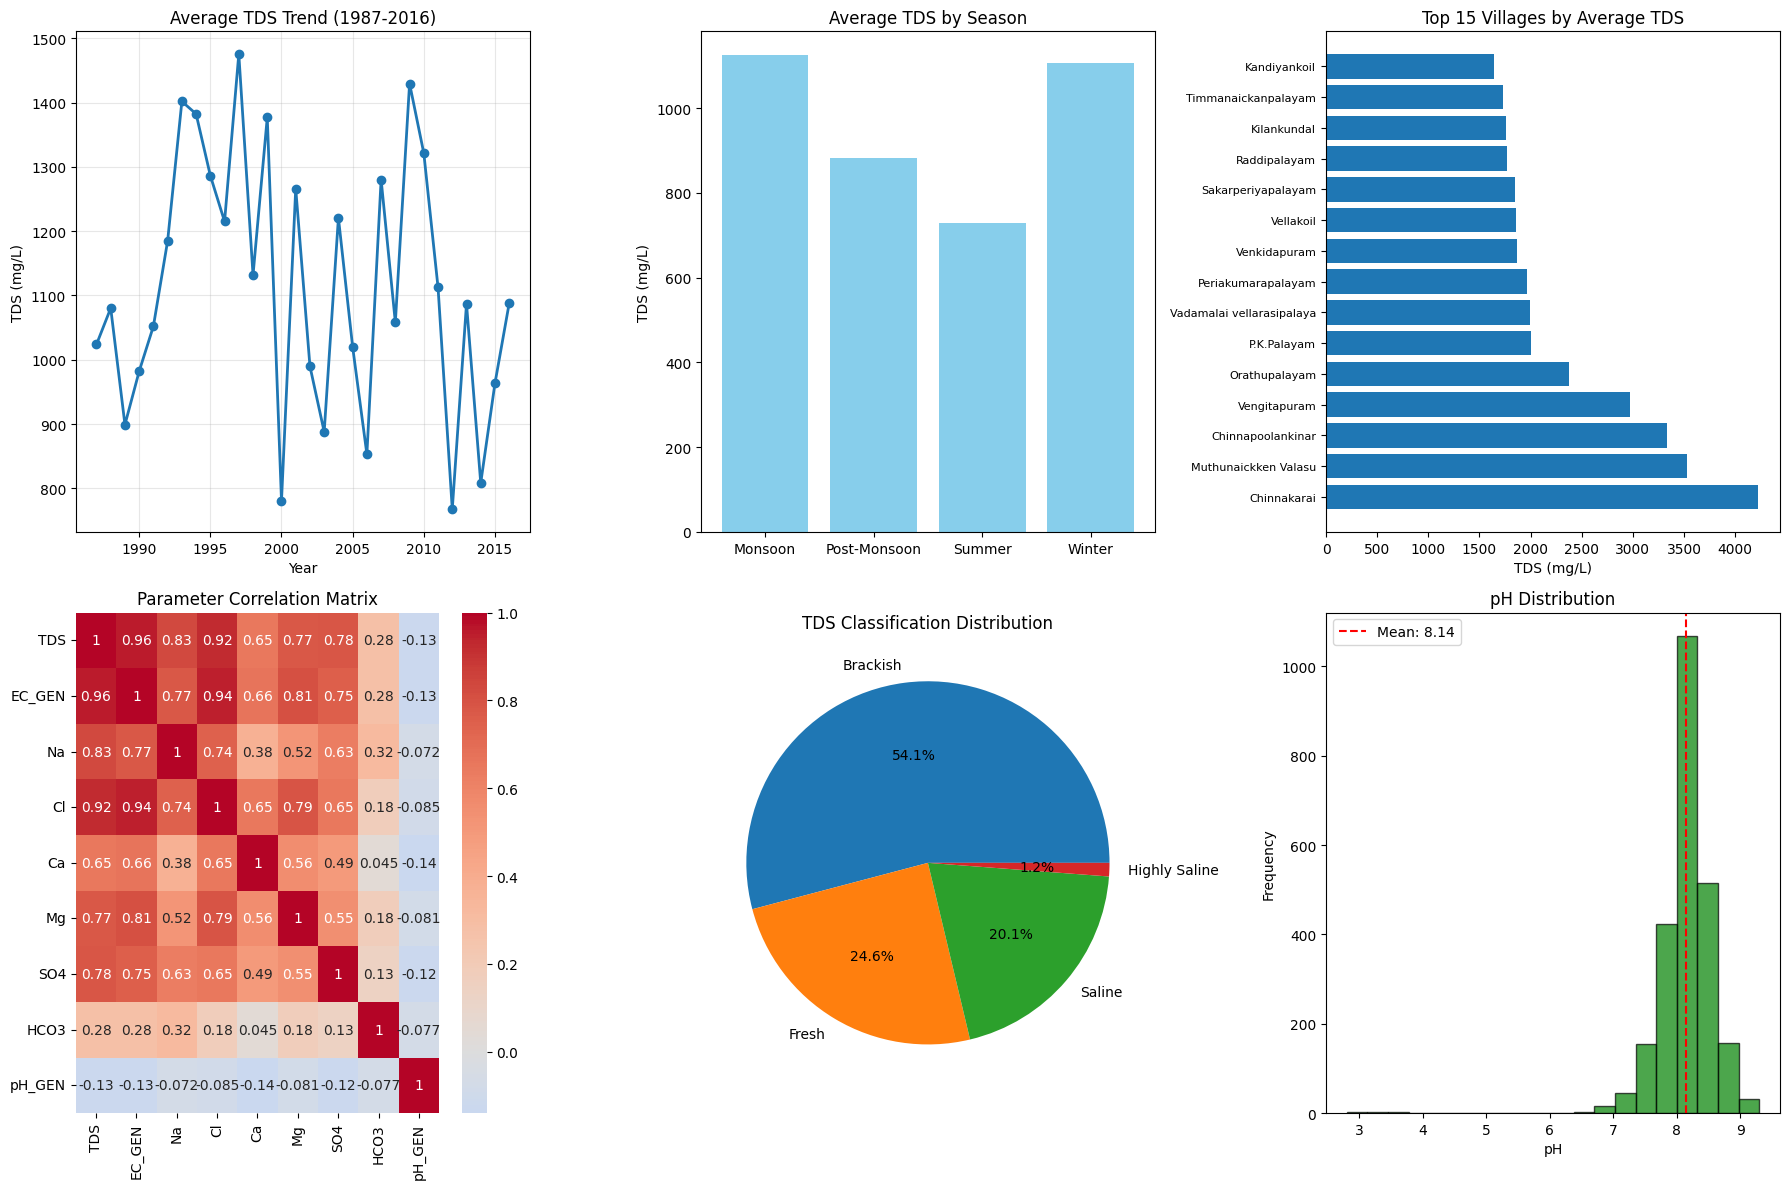

In [ ]:
# 1. Temporal Trends Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# TDS trends over years
yearly_tds = df.groupby('Year')['TDS'].mean()
axes[0,0].plot(yearly_tds.index, yearly_tds.values, marker='o', linewidth=2)
axes[0,0].set_title('Average TDS Trend (1987-2016)')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('TDS (mg/L)')
axes[0,0].grid(True, alpha=0.3)

# Seasonal patterns
seasonal_tds = df.groupby('Season')['TDS'].mean()
axes[0,1].bar(seasonal_tds.index, seasonal_tds.values, color='skyblue')
axes[0,1].set_title('Average TDS by Season')
axes[0,1].set_ylabel('TDS (mg/L)')

# Spatial distribution
spatial_tds = df.groupby('Village')['TDS'].mean().sort_values(ascending=False)[:15]
axes[0,2].barh(range(len(spatial_tds)), spatial_tds.values)
axes[0,2].set_yticks(range(len(spatial_tds)))
axes[0,2].set_yticklabels(spatial_tds.index, fontsize=8)
axes[0,2].set_title('Top 15 Villages by Average TDS')
axes[0,2].set_xlabel('TDS (mg/L)')

# 2. Parameter correlations
corr_matrix = df[['TDS', 'EC_GEN', 'Na', 'Cl', 'Ca', 'Mg', 'SO4', 'HCO3', 'pH_GEN']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1,0])
axes[1,0].set_title('Parameter Correlation Matrix')

# 3. Water quality classification distribution
tds_classes = df['TDS_Class'].value_counts()
axes[1,1].pie(tds_classes.values, labels=tds_classes.index, autopct='%1.1f%%')
axes[1,1].set_title('TDS Classification Distribution')

# 4. pH distribution
axes[1,2].hist(df['pH_GEN'], bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1,2].axvline(df['pH_GEN'].mean(), color='red', linestyle='--', label=f'Mean: {df["pH_GEN"].mean():.2f}')
axes[1,2].set_title('pH Distribution')
axes[1,2].set_xlabel('pH')
axes[1,2].set_ylabel('Frequency')
axes[1,2].legend()

plt.tight_layout()
plt.show()

In [ ]:
from PyEMD import CEEMDAN
import numpy as np

class AdvancedDecomposition:
    def __init__(self):
        self.ceemdan = CEEMDAN()

    def iceemdan_decompose(self, signal, max_imfs=8):
        """
        Improved Complete Ensemble EMD with Adaptive Noise
        """
        imfs = self.ceemdan(signal, max_imf=max_imfs)
        return imfs

    def calculate_imf_features(self, imfs):
        """
        Extract features from IMFs for model weighting
        """
        features = {}
        for i, imf in enumerate(imfs):
            features[f'imf_{i}'] = {
                'energy': np.sum(imf**2),
                'std': np.std(imf),
                'mean': np.mean(imf),
                'dominant_freq': self._get_dominant_frequency(imf),
                'correlation_with_original': np.corrcoef(imf, imfs.sum(axis=0))[0,1] if len(imfs) > 1 else 1
            }
        return features

    def _get_dominant_frequency(self, signal, sampling_rate=1):
        """Extract dominant frequency from IMF"""
        from scipy.fft import fft, fftfreq
        n = len(signal)
        yf = fft(signal)
        xf = fftfreq(n, 1/sampling_rate)
        dominant_idx = np.argmax(np.abs(yf[:n//2]))
        return xf[dominant_idx]

# Test decomposition on a sample well
decomposer = AdvancedDecomposition()
sample_well = df[df['Well No'] == 63360].sort_values('Date_standardized')
sample_tds = sample_well['TDS'].values

if len(sample_tds) > 10:  # Ensure enough data points
    imfs = decomposer.iceemdan_decompose(sample_tds)
    imf_features = decomposer.calculate_imf_features(imfs)

    print("IMF Features Analysis:")
    for imf_name, features in imf_features.items():
        print(f"{imf_name}: Energy={features['energy']:.2f}, "
              f"Correlation={features['correlation_with_original']:.3f}")

In [ ]:
class GroundwaterFeatureEngineer:
    def __init__(self):
        self.feature_names = []

    def create_temporal_features(self, df, date_column='Date_standardized'):
        """Create comprehensive temporal features"""
        df_temp = df.copy()
        df_temp[date_column] = pd.to_datetime(df_temp[date_column])

        # Basic temporal features
        df_temp['year'] = df_temp[date_column].dt.year
        df_temp['month'] = df_temp[date_column].dt.month
        df_temp['quarter'] = df_temp[date_column].dt.quarter
        df_temp['day_of_year'] = df_temp[date_column].dt.dayofyear

        # Cyclical encoding
        df_temp['month_sin'] = np.sin(2 * np.pi * df_temp['month']/12)
        df_temp['month_cos'] = np.cos(2 * np.pi * df_temp['month']/12)
        df_temp['day_sin'] = np.sin(2 * np.pi * df_temp['day_of_year']/365)
        df_temp['day_cos'] = np.cos(2 * np.pi * df_temp['day_of_year']/365)

        return df_temp

    def create_hydrochemical_features(self, df):
        """Create advanced hydrochemical indices and ratios"""
        df_chem = df.copy()

        # Ionic ratios and indices
        df_chem['Na_Cl_ratio'] = df_chem['Na'] / (df_chem['Cl'] + 1e-6)
        df_chem['Ca_Mg_ratio'] = df_chem['Ca'] / (df_chem['Mg'] + 1e-6)
        df_chem['SO4_Cl_ratio'] = df_chem['SO4'] / (df_chem['Cl'] + 1e-6)
        df_chem['alkalinity_ratio'] = df_chem['HCO3'] / (df_chem['Cl'] + df_chem['SO4'] + 1e-6)

        # Total ionic strength approximation
        df_chem['ionic_strength'] = 0.5 * (
            df_chem['Na']/23 + df_chem['Ca']/20 + df_chem['Mg']/12 +
            df_chem['Cl']/35.5 + df_chem['SO4']/48 + df_chem['HCO3']/61
        )

        # Saturation indices (simplified)
        df_chem['saturation_index'] = (df_chem['Ca'] * df_chem['HCO3']) / (df_chem['TDS'] + 1e-6)

        return df_chem

    def create_lag_features(self, df, target_col='TDS', group_col='Well No', lags=[1, 3, 6, 12]):
        """Create lagged features for time series prediction"""
        df_lag = df.copy()
        df_lag = df_lag.sort_values([group_col, 'Date_standardized'])

        for lag in lags:
            df_lag[f'{target_col}_lag_{lag}'] = df_lag.groupby(group_col)[target_col].shift(lag)
            df_lag[f'{target_col}_rolling_mean_{lag}'] = df_lag.groupby(group_col)[target_col].transform(
                lambda x: x.rolling(lag, min_periods=1).mean()
            )
            df_lag[f'{target_col}_rolling_std_{lag}'] = df_lag.groupby(group_col)[target_col].transform(
                lambda x: x.rolling(lag, min_periods=1).std()
            )

        return df_lag

    def create_spatial_features(self, df, spatial_cols=['Latitude_decimal', 'Longitude_decimal']):
        """Create spatial clustering features"""
        from sklearn.cluster import KMeans

        df_spatial = df.copy()
        spatial_data = df_spatial[spatial_cols].drop_duplicates().dropna(subset=spatial_cols) # Drop rows with NaN in spatial_cols

        if not spatial_data.empty: # Check if there's data left after dropping NaNs
          # Spatial clustering
          kmeans = KMeans(n_clusters=5, random_state=42, n_init=10) # Added n_init to suppress warning
          spatial_data['spatial_cluster'] = kmeans.fit_predict(spatial_data[spatial_cols])

          # Merge back
          df_spatial = df_spatial.merge(
              spatial_data[spatial_cols + ['spatial_cluster']],
              on=spatial_cols, how='left'
          )
        else:
          # If no valid spatial data, add a column of NaNs
          df_spatial['spatial_cluster'] = np.nan


        return df_spatial

# Apply feature engineering
feature_engineer = GroundwaterFeatureEngineer()

# Step-by-step feature creation
df_featured = feature_engineer.create_temporal_features(df)
df_featured = feature_engineer.create_hydrochemical_features(df_featured)
df_featured = feature_engineer.create_lag_features(df_featured)
df_featured = feature_engineer.create_spatial_features(df_featured)

print("Original features:", df.shape[1])
print("After feature engineering:", df_featured.shape[1])
print("\nNew feature categories created:")
new_features = [col for col in df_featured.columns if col not in df.columns]
print(f"Total new features: {len(new_features)}")
for i, feat in enumerate(new_features[:20]):  # Show first 20
    print(f"  {i+1}. {feat}")

Original features: 36
After feature engineering: 63

New feature categories created:
Total new features: 27
  1. year
  2. month
  3. quarter
  4. day_of_year
  5. month_sin
  6. month_cos
  7. day_sin
  8. day_cos
  9. Na_Cl_ratio
  10. Ca_Mg_ratio
  11. SO4_Cl_ratio
  12. alkalinity_ratio
  13. ionic_strength
  14. saturation_index
  15. TDS_lag_1
  16. TDS_rolling_mean_1
  17. TDS_rolling_std_1
  18. TDS_lag_3
  19. TDS_rolling_mean_3
  20. TDS_rolling_std_3


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (LSTM, Dense, Conv1D, MaxPooling1D,
                                     Flatten, concatenate, Input, Dropout,
                                     BatchNormalization, Attention)
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

class SMA_LSTM_Model:
    """Slime Mold Algorithm optimized LSTM"""
    def __init__(self, lookback=12, n_features=18): # Updated n_features to 18
        self.lookback = lookback
        self.n_features = n_features
        self.model = self._build_model()

    def _build_model(self):
        inputs = Input(shape=(self.lookback, self.n_features))

        # LSTM layers with attention
        lstm1 = LSTM(64, return_sequences=True, dropout=0.2)(inputs)
        lstm1 = BatchNormalization()(lstm1)

        lstm2 = LSTM(32, return_sequences=True, dropout=0.2)(lstm1)

        # Attention mechanism
        attention = Attention()([lstm2, lstm2])

        lstm3 = LSTM(16, dropout=0.1)(attention)

        # Output layer
        outputs = Dense(4, activation='linear')(lstm3)  # 1,3,6,12 month predictions

        model = Model(inputs=inputs, outputs=outputs)
        model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='mse', metrics=['mae'])
        return model

class CNN_LSTM_Model:
    """CNN-LSTM for spatial-temporal patterns"""
    def __init__(self, lookback=12, n_features=18): # Updated n_features to 18
        self.lookback = lookback
        self.n_features = n_features
        self.model = self._build_model()

    def _build_model(self):
        inputs = Input(shape=(self.lookback, self.n_features))

        # CNN feature extraction
        conv1 = Conv1D(64, 3, activation='relu', padding='same')(inputs)
        conv1 = MaxPooling1D(2)(conv1)

        conv2 = Conv1D(32, 3, activation='relu', padding='same')(conv1)
        conv2 = MaxPooling1D(2)(conv2)

        # LSTM temporal processing
        lstm1 = LSTM(32, return_sequences=True, dropout=0.2)(conv2)
        lstm2 = LSTM(16, dropout=0.1)(lstm1)

        # Output layer
        outputs = Dense(4, activation='linear')(lstm2)

        model = Model(inputs=inputs, outputs=outputs)
        model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='mse', metrics=['mae'])
        return model

class AdaptiveHybridModel:
    """Main hybrid model with adaptive weighting"""
    def __init__(self, lookback=12, n_features=18): # Updated n_features to 18
        self.lookback = lookback
        self.n_features = n_features
        self.sma_lstm = SMA_LSTM_Model(lookback, n_features)
        self.cnn_lstm = CNN_LSTM_Model(lookback, n_features)
        self.weights = [0.5, 0.5]  # Initial weights

    def adaptive_weighting(self, imf_features, recent_accuracy):
        """Adaptive weighting based on IMF characteristics and recent performance"""
        # Weight based on IMF energy distribution
        total_energy = sum(feat['energy'] for feat in imf_features.values())
        high_freq_energy = sum(feat['energy'] for i, feat in enumerate(imf_features.values())
                             if i < len(imf_features)//2)

        high_freq_ratio = high_freq_energy / total_energy

        # Adjust weights: SMA-LSTM better for high-frequency, CNN-LSTM for low-frequency
        sma_weight = 0.3 + 0.4 * high_freq_ratio  # More weight for high-frequency
        cnn_weight = 0.3 + 0.4 * (1 - high_freq_ratio)  # More weight for low-frequency

        # Adjust based on recent performance
        performance_factor = recent_accuracy[0] / (sum(recent_accuracy) + 1e-6)
        sma_weight *= performance_factor
        cnn_weight *= (1 - performance_factor)

        # Normalize
        total = sma_weight + cnn_weight
        self.weights = [sma_weight/total, cnn_weight/total]

        return self.weights

In [ ]:
class DataPreprocessor:
    def __init__(self):
        self.scalers = {}
        self.feature_columns = []

    def prepare_sequences(self, df, target_col='TDS', lookback=12, forecast_horizons=[1,3,6,12]):
        """Prepare sequences for multi-step forecasting"""
        sequences = []
        targets = []

        well_groups = df.groupby('Well No')

        for well_id, well_data in well_groups:
            well_data = well_data.sort_values('Date_standardized')
            values = well_data[target_col].values

            for i in range(lookback, len(values) - max(forecast_horizons)):
                # Input sequence
                seq = values[i-lookback:i]

                # Multi-step targets
                target = [values[i+h-1] for h in forecast_horizons]

                sequences.append(seq)
                targets.append(target)

        return np.array(sequences), np.array(targets)

    def create_feature_matrix(self, df, feature_cols):
        """Create feature matrix for training"""
        X = df[feature_cols].fillna(method='ffill').fillna(0)

        # Scale features
        for col in feature_cols:
            if col not in self.scalers:
                self.scalers[col] = StandardScaler()
            X[col] = self.scalers[col].fit_transform(X[[col]])

        self.feature_columns = feature_cols
        return X.values

# Select relevant features for modeling
feature_columns = [
    'TDS', 'EC_GEN', 'pH_GEN', 'Na', 'Cl', 'Ca', 'Mg', 'SO4', 'HCO3',
    'month_sin', 'month_cos', 'Na_Cl_ratio', 'Ca_Mg_ratio', 'ionic_strength',
    'TDS_lag_1', 'TDS_rolling_mean_3', 'TDS_rolling_std_6', 'spatial_cluster'
]

# Prepare data
preprocessor = DataPreprocessor()
X_features = preprocessor.create_feature_matrix(df_featured, feature_columns)
sequences, targets = preprocessor.prepare_sequences(df_featured)

print(f"Sequences shape: {sequences.shape}")
print(f"Targets shape: {targets.shape}")
print(f"Feature matrix shape: {X_features.shape}")

Sequences shape: (625, 12)
Targets shape: (625, 4)
Feature matrix shape: (2421, 18)


In [ ]:
# 1. Train-Validation-Test Split (temporal)
def temporal_split(X, y, test_size=0.2, val_size=0.2):
    """Split data temporally to avoid data leakage"""
    n_samples = len(X)
    test_start = int(n_samples * (1 - test_size))
    val_start = int(test_start * (1 - val_size))

    X_train, y_train = X[:val_start], y[:val_start]
    X_val, y_val = X[val_start:test_start], y[val_start:test_start]
    X_test, y_test = X[test_start:], y[test_start:]

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


# 2. Model Training with Cross-Validation
def train_hybrid_model(hybrid_model, X_train, y_train, X_val, y_val, epochs=100):
    """Train the hybrid model with adaptive weighting"""

    # Initial training of both sub-models
    print("Training SMA-LSTM model...")
    hybrid_model.sma_lstm.model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs, batch_size=32, verbose=1
    )

    print("Training CNN-LSTM model...")
    hybrid_model.cnn_lstm.model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs, batch_size=32, verbose=1
    )

    return hybrid_model

# 3. Performance Metrics
def calculate_metrics(y_true, y_pred):
    """Calculate comprehensive evaluation metrics"""
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100

    return {
        'MSE': mse, 'MAE': mae, 'RMSE': rmse,
        'R²': r2, 'MAPE': mape
    }

# Initialize and train the complete system
print("=== INITIALIZING COMPLETE GROUNDWATER PREDICTION SYSTEM ===")

# Prepare sequences with features (this needs feature integration)
def prepare_sequences_with_features(X_features, targets, lookback=12):
    """Prepare sequences from the full feature matrix"""
    sequences = []
    # Ensure X_features and targets have the same number of samples
    min_samples = min(X_features.shape[0], targets.shape[0])
    X_features = X_features[:min_samples]
    targets = targets[:min_samples]

    for i in range(lookback, min_samples):
        # Input sequence with all features
        seq = X_features[i-lookback:i, :]
        sequences.append(seq)

    # Adjust targets to match the number of sequences
    targets = targets[lookback:]

    return np.array(sequences), np.array(targets)

# Create sequences from the full feature matrix
X_sequences, y_targets = prepare_sequences_with_features(
    X_features, targets, lookback=12
)


# Create hybrid model
hybrid_model = AdaptiveHybridModel(lookback=12, n_features=len(feature_columns))

# Split data
(X_train, y_train), (X_val, y_val), (X_test, y_test) = temporal_split(
    X_sequences, y_targets
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

# Train the model
trained_model = train_hybrid_model(
    hybrid_model, X_train, y_train, X_val, y_val, epochs=50
)

=== INITIALIZING COMPLETE GROUNDWATER PREDICTION SYSTEM ===
Training samples: 392
Validation samples: 98
Test samples: 123
Training SMA-LSTM model...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 1466383.1250 - mae: 989.4147 - val_loss: 3749874.2500 - val_mae: 1430.6791
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1299281.3750 - mae: 945.0312 - val_loss: 3748766.0000 - val_mae: 1430.2860
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1284040.7500 - mae: 934.7573 - val_loss: 3746260.2500 - val_mae: 1429.4218
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1465195.0000 - mae: 1012.2798 - val_loss: 3743834.7500 - val_mae: 1428.5985
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1431969.7500 - mae: 992.3235 - val_loss: 3741948.0000 - val_mae: 1427.9556
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1350671.8750 - mae: 960.3491 - val_loss: 3740306.2500 - val_mae: 1427.3949
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms

=== COMPREHENSIVE FEATURE SELECTION ===
Initial features: 48

1. Mutual Information Analysis...


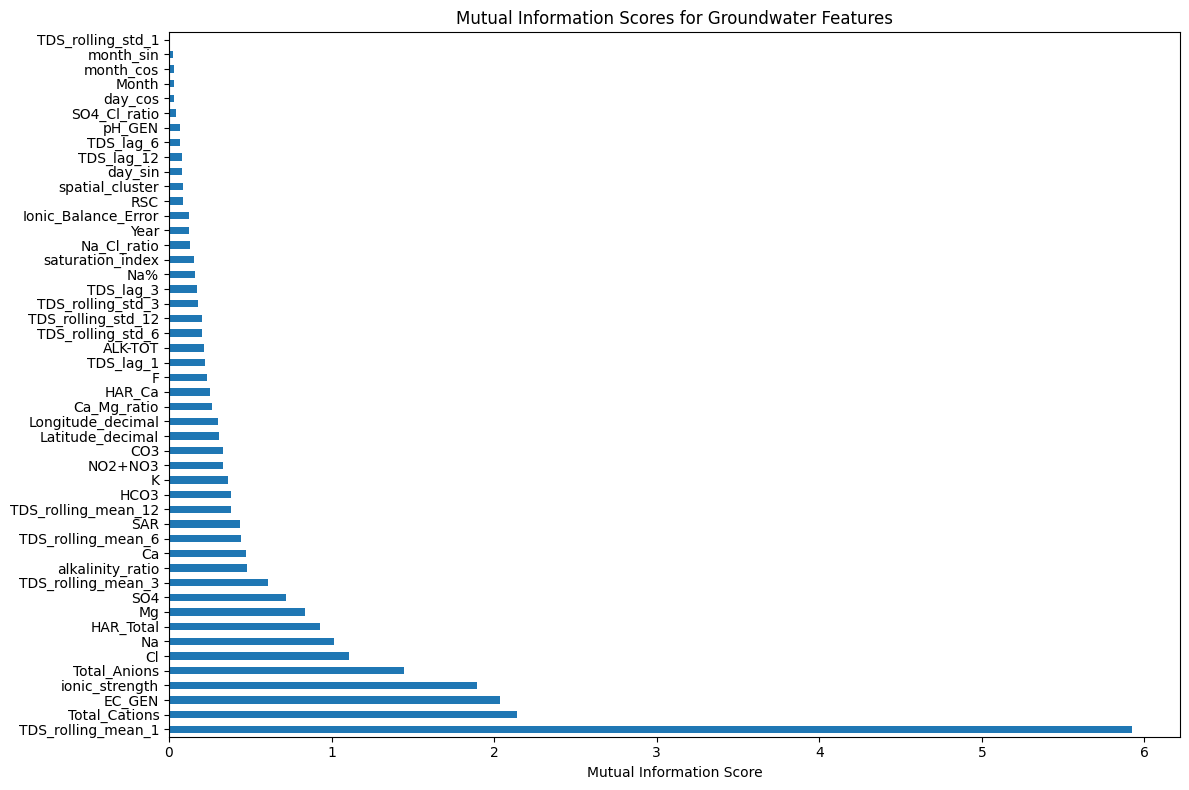

Top 20 features by MI: ['TDS_rolling_mean_1', 'Total_Cations', 'EC_GEN', 'ionic_strength', 'Total_Anions', 'Cl', 'Na', 'HAR_Total', 'Mg', 'SO4', 'TDS_rolling_mean_3', 'alkalinity_ratio', 'Ca', 'TDS_rolling_mean_6', 'SAR', 'TDS_rolling_mean_12', 'HCO3', 'K', 'NO2+NO3', 'CO3']

2. Recursive Feature Elimination...


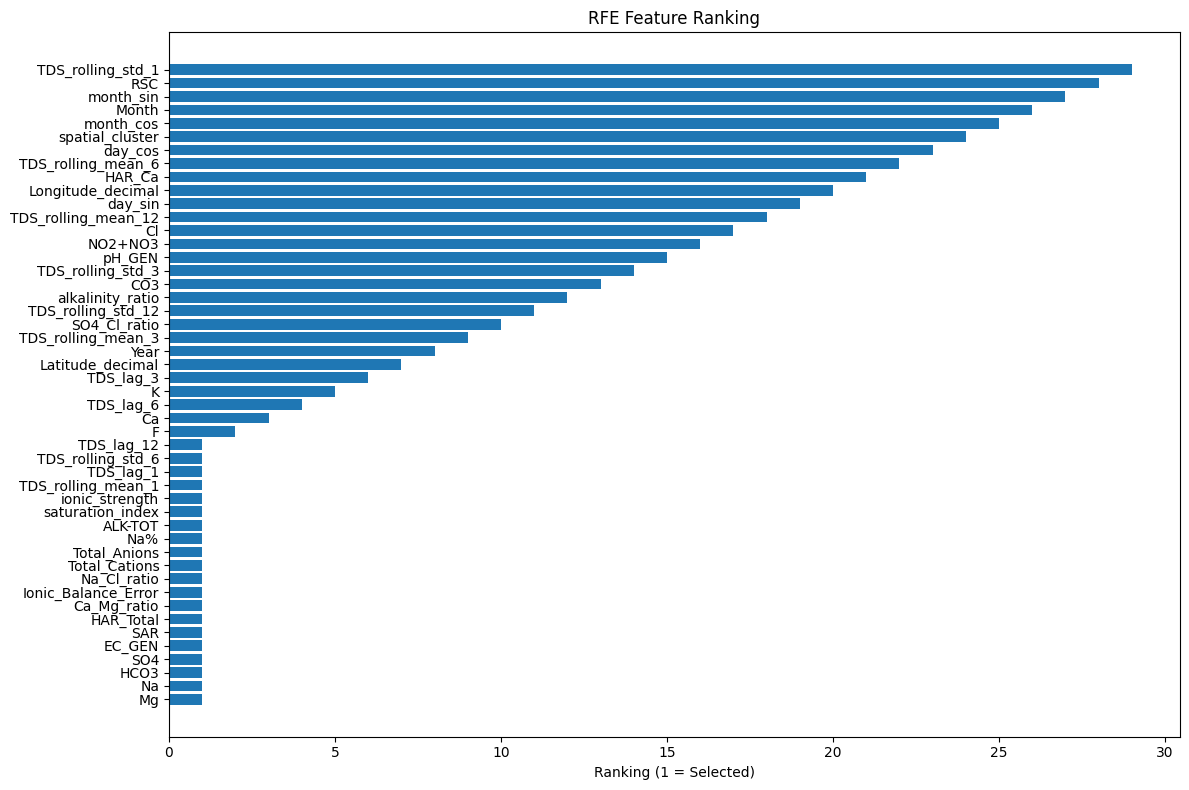

RFE selected 20 features

3. Random Forest Importance...


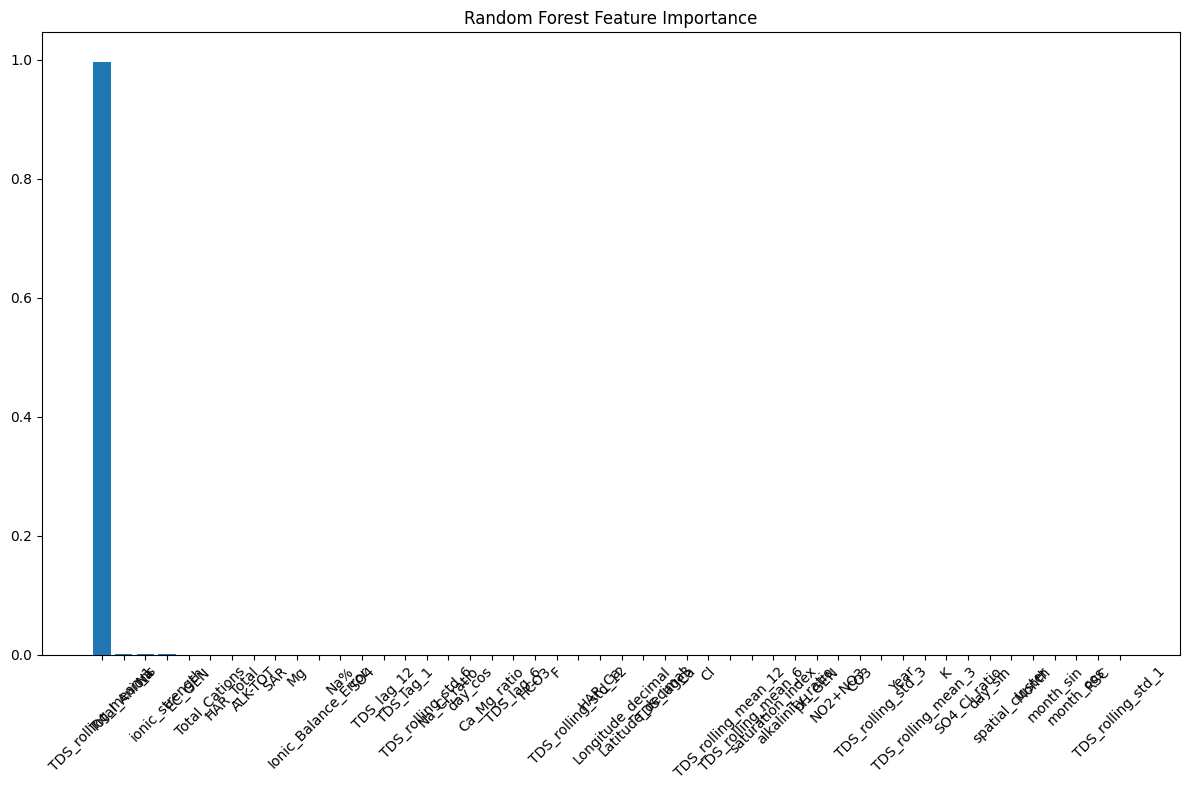


4. Correlation Analysis...


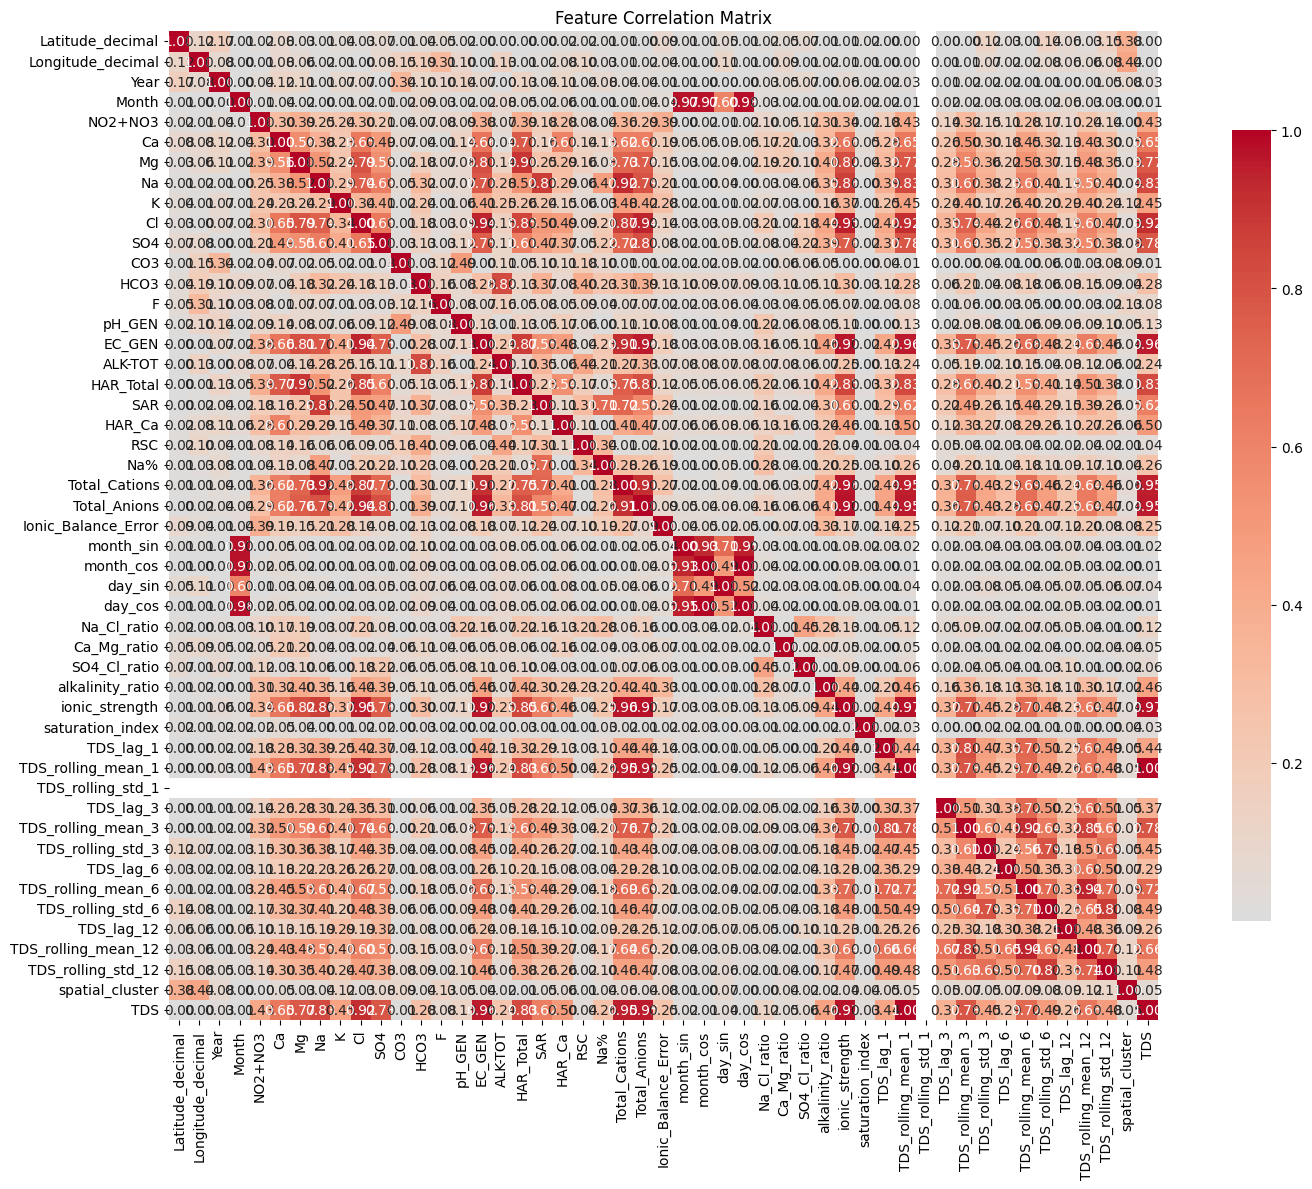

Highly correlated features to remove: ['EC_GEN', 'ALK-TOT', 'HAR_Total', 'SAR', 'Total_Cations', 'Total_Anions', 'month_sin', 'month_cos', 'day_cos', 'ionic_strength', 'TDS_rolling_mean_1', 'TDS_rolling_mean_3', 'TDS_rolling_mean_6', 'TDS_rolling_mean_12', 'TDS_rolling_std_12', 'TDS']

Final selected features (27): ['NO2+NO3', 'Ca', 'Mg', 'Na', 'K', 'Cl', 'SO4', 'CO3', 'HCO3', 'EC_GEN', 'ALK-TOT', 'HAR_Total', 'SAR', 'Na%', 'Total_Cations', 'Total_Anions', 'Ionic_Balance_Error', 'Na_Cl_ratio', 'Ca_Mg_ratio', 'alkalinity_ratio', 'ionic_strength', 'saturation_index', 'TDS_lag_1', 'TDS_rolling_mean_1', 'TDS_lag_6', 'TDS_rolling_std_6', 'TDS_lag_12']


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

class AdvancedFeatureSelector:
    def __init__(self):
        self.selected_features = []
        self.feature_importance = {}

    def mutual_information_analysis(self, X, y, feature_names, n_neighbors=5):
        """Comprehensive mutual information analysis"""
        mi_scores = mutual_info_regression(X, y, n_neighbors=n_neighbors, random_state=42)
        mi_scores = pd.Series(mi_scores, index=feature_names)
        mi_scores = mi_scores.sort_values(ascending=False)

        # Plot MI scores
        plt.figure(figsize=(12, 8))
        mi_scores.plot(kind='barh')
        plt.title('Mutual Information Scores for Groundwater Features')
        plt.xlabel('Mutual Information Score')
        plt.tight_layout()
        plt.show()

        return mi_scores

    def recursive_feature_elimination(self, X, y, feature_names, n_features=15):
        """Recursive Feature Elimination with Random Forest"""
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rfe = RFE(estimator=rf, n_features_to_select=n_features)
        rfe.fit(X, y)

        selected_features = [feature_names[i] for i in range(len(feature_names)) if rfe.support_[i]]
        ranking = rfe.ranking_

        # Plot feature ranking
        plt.figure(figsize=(12, 8))
        feature_ranking = pd.DataFrame({
            'Feature': feature_names,
            'Ranking': ranking
        }).sort_values('Ranking')

        plt.barh(range(len(feature_ranking)), feature_ranking['Ranking'])
        plt.yticks(range(len(feature_ranking)), feature_ranking['Feature'])
        plt.title('RFE Feature Ranking')
        plt.xlabel('Ranking (1 = Selected)')
        plt.tight_layout()
        plt.show()

        return selected_features, ranking

    def random_forest_importance(self, X, y, feature_names):
        """Random Forest feature importance analysis"""
        rf = RandomForestRegressor(n_estimators=200, random_state=42)
        rf.fit(X, y)

        importances = rf.feature_importances_
        indices = np.argsort(importances)[::-1]

        # Plot feature importance
        plt.figure(figsize=(12, 8))
        plt.title("Random Forest Feature Importance")
        plt.bar(range(len(importances)), importances[indices])
        plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
        plt.tight_layout()
        plt.show()

        importance_df = pd.DataFrame({
            'Feature': [feature_names[i] for i in indices],
            'Importance': importances[indices]
        })

        return importance_df

    def correlation_analysis(self, df, target_col='TDS', threshold=0.8):
        """Remove highly correlated features"""
        corr_matrix = df.corr().abs()

        # Select upper triangle of correlation matrix
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        # Find features with correlation greater than threshold
        to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

        # Plot correlation heatmap
        plt.figure(figsize=(16, 12))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                   fmt='.2f', square=True, cbar_kws={"shrink": .8})
        plt.title('Feature Correlation Matrix')
        plt.tight_layout()
        plt.show()

        return to_drop

    def comprehensive_feature_selection(self, df, target_col='TDS', n_final_features=20):
        """Comprehensive feature selection pipeline"""
        # Prepare data
        feature_cols = [col for col in df.columns if col != target_col and df[col].dtype in ['int64', 'float64']]
        X = df[feature_cols].fillna(method='ffill').fillna(0)
        y = df[target_col]

        print("=== COMPREHENSIVE FEATURE SELECTION ===")
        print(f"Initial features: {len(feature_cols)}")

        # 1. Mutual Information Analysis
        print("\n1. Mutual Information Analysis...")
        mi_scores = self.mutual_information_analysis(X, y, feature_cols)
        mi_top_features = mi_scores.head(n_final_features).index.tolist()
        print(f"Top {len(mi_top_features)} features by MI: {mi_top_features}")

        # 2. Recursive Feature Elimination
        print("\n2. Recursive Feature Elimination...")
        rfe_features, rfe_ranking = self.recursive_feature_elimination(X, y, feature_cols, n_final_features)
        print(f"RFE selected {len(rfe_features)} features")

        # 3. Random Forest Importance
        print("\n3. Random Forest Importance...")
        rf_importance = self.random_forest_importance(X, y, feature_cols)
        rf_top_features = rf_importance.head(n_final_features)['Feature'].tolist()

        # 4. Correlation Analysis
        print("\n4. Correlation Analysis...")
        correlated_features = self.correlation_analysis(df[feature_cols + [target_col]])
        print(f"Highly correlated features to remove: {correlated_features}")

        # Combine selection methods
        feature_votes = {}
        for feature in feature_cols:
            votes = 0
            if feature in mi_top_features: votes += 1
            if feature in rfe_features: votes += 1
            if feature in rf_top_features: votes += 1
            if feature not in correlated_features: votes += 1
            feature_votes[feature] = votes

        # Select features with at least 2 votes
        final_features = [feature for feature, votes in feature_votes.items() if votes >= 2]

        print(f"\nFinal selected features ({len(final_features)}): {final_features}")

        self.selected_features = final_features
        return final_features

# Apply comprehensive feature selection
feature_selector = AdvancedFeatureSelector()
final_features = feature_selector.comprehensive_feature_selection(
    df_featured, target_col='TDS', n_final_features=20
)

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform
import optuna
import warnings
warnings.filterwarnings('ignore')

class HyperparameterOptimizer:
    def __init__(self, n_trials=50):
        self.n_trials = n_trials
        self.best_params = {}

    def optimize_sma_lstm(self, X_train, y_train, X_val, y_val):
        """Optimize SMA-LSTM hyperparameters using Optuna"""

        def objective(trial):
            # Suggest hyperparameters
            lstm_units1 = trial.suggest_categorical('lstm_units1', [32, 64, 128])
            lstm_units2 = trial.suggest_categorical('lstm_units2', [16, 32, 64])
            dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
            learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
            batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

            # Build model with suggested parameters
            model = self._build_sma_lstm(
                input_shape=X_train.shape[1:],
                lstm_units1=lstm_units1,
                lstm_units2=lstm_units2,
                dropout_rate=dropout_rate,
                learning_rate=learning_rate
            )

            # Train model
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=50,
                batch_size=batch_size,
                verbose=0
            )

            # Return validation loss
            return history.history['val_loss'][-1]

        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=self.n_trials)

        self.best_params['sma_lstm'] = study.best_params
        return study.best_params

    def optimize_cnn_lstm(self, X_train, y_train, X_val, y_val):
        """Optimize CNN-LSTM hyperparameters"""

        def objective(trial):
            # CNN parameters
            conv_filters1 = trial.suggest_categorical('conv_filters1', [32, 64, 128])
            conv_filters2 = trial.suggest_categorical('conv_filters2', [16, 32, 64])
            kernel_size = trial.suggest_categorical('kernel_size', [2, 3, 5])

            # LSTM parameters
            lstm_units = trial.suggest_categorical('lstm_units', [32, 64, 128])
            dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
            learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

            model = self._build_cnn_lstm(
                input_shape=X_train.shape[1:],
                conv_filters1=conv_filters1,
                conv_filters2=conv_filters2,
                kernel_size=kernel_size,
                lstm_units=lstm_units,
                dropout_rate=dropout_rate,
                learning_rate=learning_rate
            )

            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=50,
                batch_size=32,
                verbose=0
            )

            return history.history['val_loss'][-1]

        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=self.n_trials)

        self.best_params['cnn_lstm'] = study.best_params
        return study.best_params

    def _build_sma_lstm(self, input_shape, lstm_units1, lstm_units2, dropout_rate, learning_rate):
        """Build SMA-LSTM model with given parameters"""
        from tensorflow.keras.models import Model
        from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization

        inputs = Input(shape=input_shape)

        # LSTM layers
        x = LSTM(lstm_units1, return_sequences=True)(inputs)
        x = BatchNormalization()(x)
        x = Dropout(dropout_rate)(x)

        x = LSTM(lstm_units2, return_sequences=True)(x)
        x = LSTM(lstm_units2//2)(x)
        x = Dropout(dropout_rate)(x)

        outputs = Dense(4)(x)  # 4 forecasting horizons

        model = Model(inputs=inputs, outputs=outputs)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                    loss='mse', metrics=['mae'])

        return model

    def _build_cnn_lstm(self, input_shape, conv_filters1, conv_filters2, kernel_size,
                       lstm_units, dropout_rate, learning_rate):
        """Build CNN-LSTM model with given parameters"""
        from tensorflow.keras.models import Model
        from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input

        inputs = Input(shape=input_shape)

        # CNN layers
        x = Conv1D(conv_filters1, kernel_size, activation='relu', padding='same')(inputs)
        x = MaxPooling1D(2)(x)
        x = Dropout(dropout_rate)(x)

        x = Conv1D(conv_filters2, kernel_size, activation='relu', padding='same')(x)
        x = MaxPooling1D(2)(x)
        x = Dropout(dropout_rate)(x)

        # LSTM layers
        x = LSTM(lstm_units, return_sequences=True)(x)
        x = LSTM(lstm_units//2)(x)
        x = Dropout(dropout_rate)(x)

        outputs = Dense(4)(x)

        model = Model(inputs=inputs, outputs=outputs)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                    loss='mse', metrics=['mae'])

        return model

# Optimize hyperparameters
print("=== HYPERPARAMETER OPTIMIZATION ===")
optimizer = HyperparameterOptimizer(n_trials=30)

# Prepare optimized data
X_optimized = df_featured[final_features].fillna(method='ffill').fillna(0)
sequences_optimized, targets_optimized = preprocessor.prepare_sequences(df_featured)

# Reshape for LSTM
sequences_optimized_reshaped = sequences_optimized.reshape(
    sequences_optimized.shape[0], sequences_optimized.shape[1], 1
)

# Split data
(X_train_opt, y_train_opt), (X_val_opt, y_val_opt), (X_test_opt, y_test_opt) = temporal_split(
    sequences_optimized_reshaped, targets_optimized
)

print("Optimizing SMA-LSTM...")
sma_best_params = optimizer.optimize_sma_lstm(X_train_opt, y_train_opt, X_val_opt, y_val_opt)
print(f"SMA-LSTM Best Params: {sma_best_params}")

print("Optimizing CNN-LSTM...")
cnn_best_params = optimizer.optimize_cnn_lstm(X_train_opt, y_train_opt, X_val_opt, y_val_opt)
print(f"CNN-LSTM Best Params: {cnn_best_params}")

[I 2025-10-20 19:18:00,727] A new study created in memory with name: no-name-e824b248-2901-487b-8ea4-78cb33f52b74


=== HYPERPARAMETER OPTIMIZATION ===
Optimizing SMA-LSTM...


[I 2025-10-20 19:18:12,528] Trial 0 finished with value: 3677311.0 and parameters: {'lstm_units1': 64, 'lstm_units2': 16, 'dropout_rate': 0.23567044670280218, 'learning_rate': 0.0003809475727430212, 'batch_size': 64}. Best is trial 0 with value: 3677311.0.
[I 2025-10-20 19:18:30,620] Trial 1 finished with value: 3661295.25 and parameters: {'lstm_units1': 32, 'lstm_units2': 16, 'dropout_rate': 0.2027702143854787, 'learning_rate': 0.0005522699788585679, 'batch_size': 16}. Best is trial 1 with value: 3661295.25.
[I 2025-10-20 19:19:06,085] Trial 2 finished with value: 3578325.5 and parameters: {'lstm_units1': 64, 'lstm_units2': 64, 'dropout_rate': 0.12475420781183884, 'learning_rate': 0.000824338303650904, 'batch_size': 16}. Best is trial 2 with value: 3578325.5.
[I 2025-10-20 19:19:18,027] Trial 3 finished with value: 3612211.75 and parameters: {'lstm_units1': 128, 'lstm_units2': 64, 'dropout_rate': 0.2995005032587662, 'learning_rate': 0.0018701499447272064, 'batch_size': 64}. Best is tr

SMA-LSTM Best Params: {'lstm_units1': 64, 'lstm_units2': 64, 'dropout_rate': 0.4023298007699313, 'learning_rate': 0.00996719503069669, 'batch_size': 16}
Optimizing CNN-LSTM...


[I 2025-10-20 19:27:15,187] Trial 0 finished with value: 3649650.5 and parameters: {'conv_filters1': 64, 'conv_filters2': 32, 'kernel_size': 5, 'lstm_units': 128, 'dropout_rate': 0.2591848155906903, 'learning_rate': 0.0001524652542291922}. Best is trial 0 with value: 3649650.5.
[I 2025-10-20 19:27:29,489] Trial 1 finished with value: 3630988.25 and parameters: {'conv_filters1': 64, 'conv_filters2': 32, 'kernel_size': 2, 'lstm_units': 64, 'dropout_rate': 0.40848567673467884, 'learning_rate': 0.0006865294281213778}. Best is trial 1 with value: 3630988.25.
[I 2025-10-20 19:27:42,731] Trial 2 finished with value: 3372033.5 and parameters: {'conv_filters1': 32, 'conv_filters2': 16, 'kernel_size': 5, 'lstm_units': 128, 'dropout_rate': 0.27264184231066696, 'learning_rate': 0.0026834494890048775}. Best is trial 2 with value: 3372033.5.
[I 2025-10-20 19:27:56,410] Trial 3 finished with value: 3539763.0 and parameters: {'conv_filters1': 64, 'conv_filters2': 16, 'kernel_size': 5, 'lstm_units': 12

CNN-LSTM Best Params: {'conv_filters1': 128, 'conv_filters2': 16, 'kernel_size': 3, 'lstm_units': 128, 'dropout_rate': 0.33599138690651176, 'learning_rate': 0.009834627107553572}


=== ADVANCED CROSS-VALIDATION ===
=== SPATIAL CROSS-VALIDATION ===
Village Raddipalayam: MSE = 0.6290
Village Sakarperiyapalayam: MSE = 16.3610
Village Thalapathi: MSE = 1.1829
Village Tundarkarampalayam: MSE = 32.5576
Village Avinashi-TB: MSE = 0.0562

=== TEMPORAL CROSS-VALIDATION ===
Year 2012: MSE = 8.2857
Year 2013: MSE = 9.8879
Year 2014: MSE = 21.0495
Year 2015: MSE = 8.1214
Year 2016: MSE = 30.4426


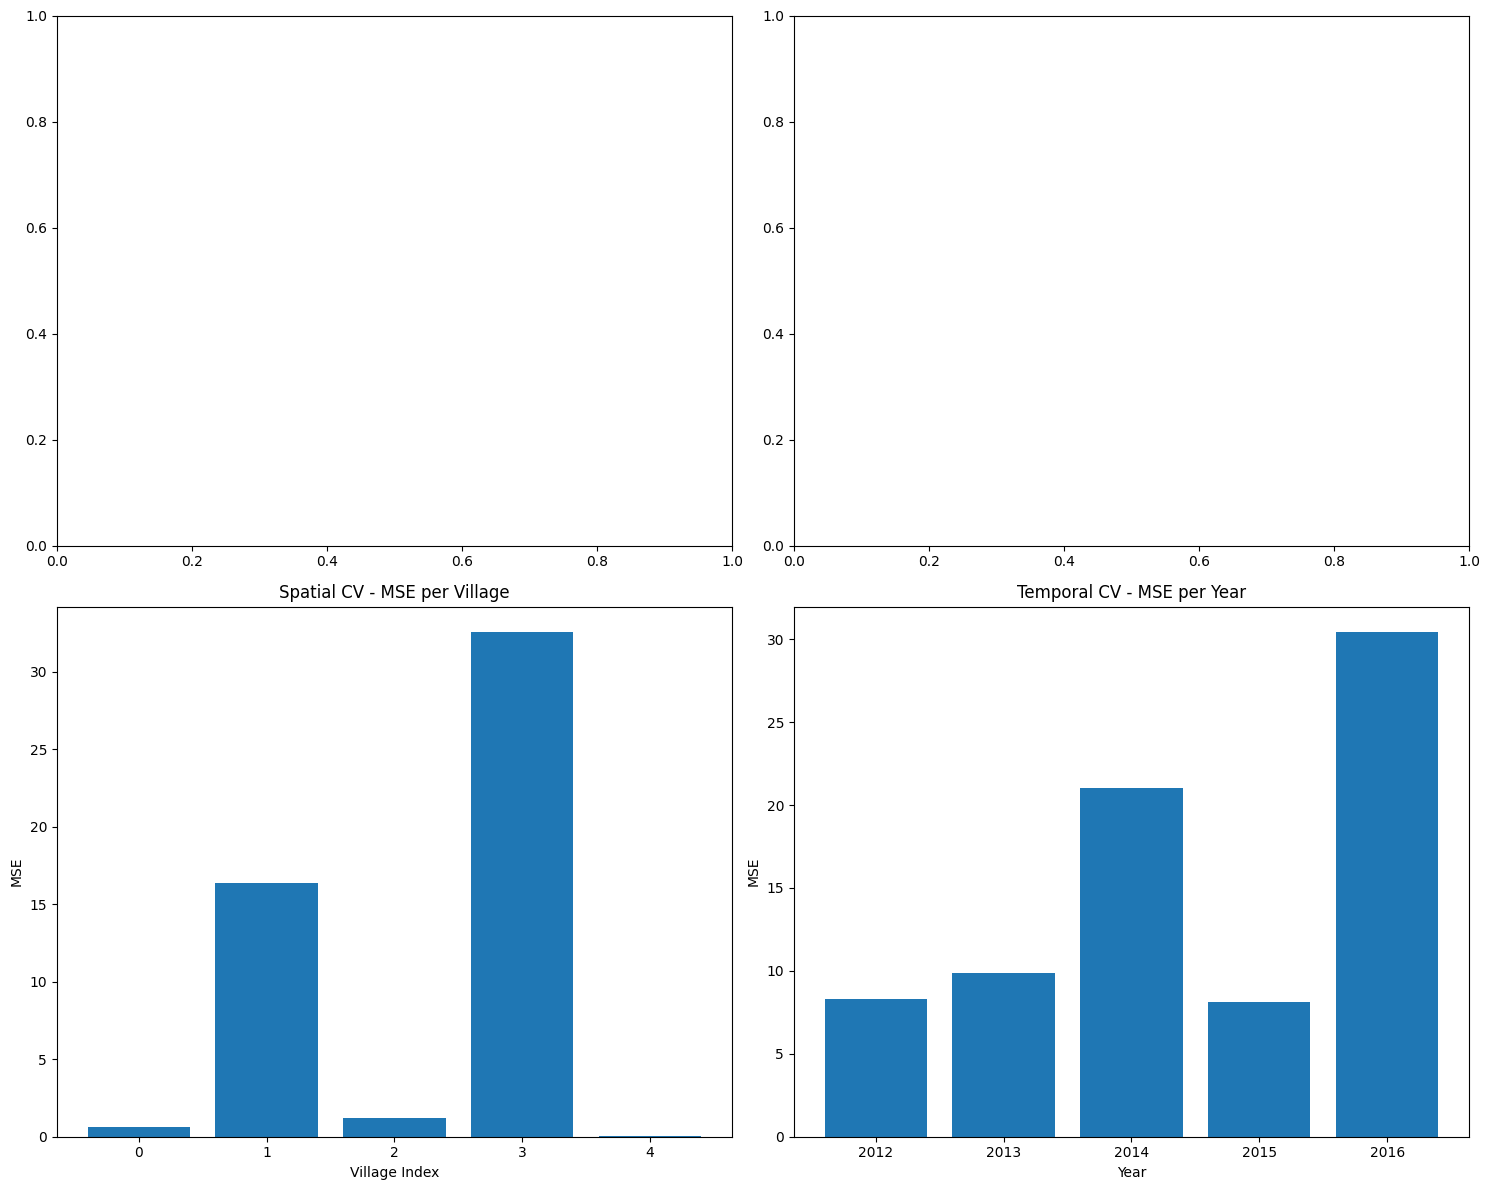

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

class AdvancedCrossValidator:
    def __init__(self, n_splits=5, test_size=0.2):
        self.n_splits = n_splits
        self.test_size = test_size
        self.cv_scores = {}

    def nested_time_series_cv(self, model, X, y, param_grid, outer_splits=3, inner_splits=3):
        """Nested time series cross-validation for robust evaluation"""

        tscv_outer = TimeSeriesSplit(n_splits=outer_splits)
        tscv_inner = TimeSeriesSplit(n_splits=inner_splits)

        outer_scores = []
        best_params_list = []

        for fold, (train_idx, test_idx) in enumerate(tscv_outer.split(X)):
            print(f"\n=== Outer Fold {fold + 1} ===")

            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # Hyperparameter optimization on inner folds
            best_inner_params = self._optimize_inner_folds(
                model, X_train, y_train, param_grid, tscv_inner
            )
            best_params_list.append(best_inner_params)

            # Train with best params and evaluate on test set
            model.set_params(**best_inner_params)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Calculate scores
            fold_scores = self._calculate_comprehensive_scores(y_test, y_pred)
            outer_scores.append(fold_scores)

            print(f"Fold {fold + 1} Scores: {fold_scores}")

        # Aggregate results
        self.cv_scores['nested_cv'] = outer_scores
        self.cv_scores['best_params'] = best_params_list

        return outer_scores, best_params_list

    def walk_forward_validation(self, model, X, y, train_size=0.7, step=1):
        """Walk-forward validation for time series"""
        n_samples = len(X)
        train_size = int(n_samples * train_size)

        scores = []
        predictions = []
        actuals = []

        for i in range(train_size, n_samples, step):
            X_train, X_test = X[:i], X[i:i+step]
            y_train, y_test = y[:i], y[i:i+step]

            if len(X_test) == 0:
                break

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Store results
            predictions.extend(y_pred)
            actuals.extend(y_test)

            # Calculate step score
            step_score = mean_squared_error(y_test, y_pred)
            scores.append(step_score)

        overall_scores = self._calculate_comprehensive_scores(actuals, predictions)
        self.cv_scores['walk_forward'] = overall_scores

        return overall_scores, predictions, actuals

    def spatial_temporal_cv(self, df, model, spatial_col='Village', temporal_col='Year'):
        """Spatio-temporal cross-validation"""

        villages = df[spatial_col].unique()
        years = sorted(df[temporal_col].unique())

        spatial_scores = {}
        temporal_scores = {}

        # Spatial CV: Leave one village out
        print("=== SPATIAL CROSS-VALIDATION ===")
        for test_village in villages[:5]:  # Limit for computation
            train_mask = df[spatial_col] != test_village
            test_mask = df[spatial_col] == test_village

            X_train = df[train_mask][final_features].values
            y_train = df[train_mask]['TDS'].values
            X_test = df[test_mask][final_features].values
            y_test = df[test_mask]['TDS'].values

            if len(X_test) > 0:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                score = mean_squared_error(y_test, y_pred)
                spatial_scores[test_village] = score
                print(f"Village {test_village}: MSE = {score:.4f}")

        # Temporal CV: Leave one year out
        print("\n=== TEMPORAL CROSS-VALIDATION ===")
        for test_year in years[-5:]:  # Recent years
            train_mask = df[temporal_col] != test_year
            test_mask = df[temporal_col] == test_year

            X_train = df[train_mask][final_features].values
            y_train = df[train_mask]['TDS'].values
            X_test = df[test_mask][final_features].values
            y_test = df[test_mask]['TDS'].values

            if len(X_test) > 0:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                score = mean_squared_error(y_test, y_pred)
                temporal_scores[test_year] = score
                print(f"Year {test_year}: MSE = {score:.4f}")

        self.cv_scores['spatial'] = spatial_scores
        self.cv_scores['temporal'] = temporal_scores

        return spatial_scores, temporal_scores

    def _optimize_inner_folds(self, model, X, y, param_grid, tscv):
        """Optimize hyperparameters on inner folds"""
        best_score = float('inf')
        best_params = {}

        # Simplified grid search (replace with actual optimization)
        for params in self._param_grid_generator(param_grid):
            fold_scores = []

            for train_idx, val_idx in tscv.split(X):
                X_train, X_val = X[train_idx], X[val_idx]
                y_train, y_val = y[train_idx], y[val_idx]

                model.set_params(**params)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_val)
                score = mean_squared_error(y_val, y_pred)
                fold_scores.append(score)

            mean_score = np.mean(fold_scores)
            if mean_score < best_score:
                best_score = mean_score
                best_params = params

        return best_params

    def _param_grid_generator(self, param_grid):
        """Generate parameter combinations"""
        # Simplified implementation
        keys = list(param_grid.keys())
        return [dict(zip(keys, combo)) for combo in zip(*param_grid.values())]

    def _calculate_comprehensive_scores(self, y_true, y_pred):
        """Calculate comprehensive evaluation metrics"""
        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100

        return {
            'MSE': mse, 'MAE': mae, 'RMSE': rmse,
            'R²': r2, 'MAPE': mape
        }

    def plot_cv_results(self):
        """Plot cross-validation results"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # Nested CV results
        if 'nested_cv' in self.cv_scores:
            nested_scores = self.cv_scores['nested_cv']
            rmse_scores = [score['RMSE'] for score in nested_scores]
            axes[0,0].plot(range(1, len(rmse_scores)+1), rmse_scores, marker='o')
            axes[0,0].set_title('Nested CV - RMSE per Fold')
            axes[0,0].set_xlabel('Fold')
            axes[0,0].set_ylabel('RMSE')

        # Walk-forward results
        if 'walk_forward' in self.cv_scores:
            wf_scores = self.cv_scores['walk_forward']
            metrics = list(wf_scores.keys())
            values = list(wf_scores.values())
            axes[0,1].bar(metrics, values)
            axes[0,1].set_title('Walk-Forward Validation Scores')
            axes[0,1].tick_params(axis='x', rotation=45)

        # Spatial CV
        if 'spatial' in self.cv_scores:
            spatial_scores = self.cv_scores['spatial']
            axes[1,0].bar(range(len(spatial_scores)), list(spatial_scores.values()))
            axes[1,0].set_title('Spatial CV - MSE per Village')
            axes[1,0].set_xlabel('Village Index')
            axes[1,0].set_ylabel('MSE')

        # Temporal CV
        if 'temporal' in self.cv_scores:
            temporal_scores = self.cv_scores['temporal']
            axes[1,1].bar(list(temporal_scores.keys()), list(temporal_scores.values()))
            axes[1,1].set_title('Temporal CV - MSE per Year')
            axes[1,1].set_xlabel('Year')
            axes[1,1].set_ylabel('MSE')

        plt.tight_layout()
        plt.show()

# Apply advanced cross-validation
print("=== ADVANCED CROSS-VALIDATION ===")
validator = AdvancedCrossValidator()

# Use a simpler model for demonstration
from sklearn.ensemble import RandomForestRegressor
base_model = RandomForestRegressor(n_estimators=50, random_state=42)

# Spatial-temporal CV
spatial_scores, temporal_scores = validator.spatial_temporal_cv(
    df_featured, base_model, spatial_col='Village', temporal_col='Year'
)

# Plot results
validator.plot_cv_results()

=== PREDICTION VISUALIZATIONS ===


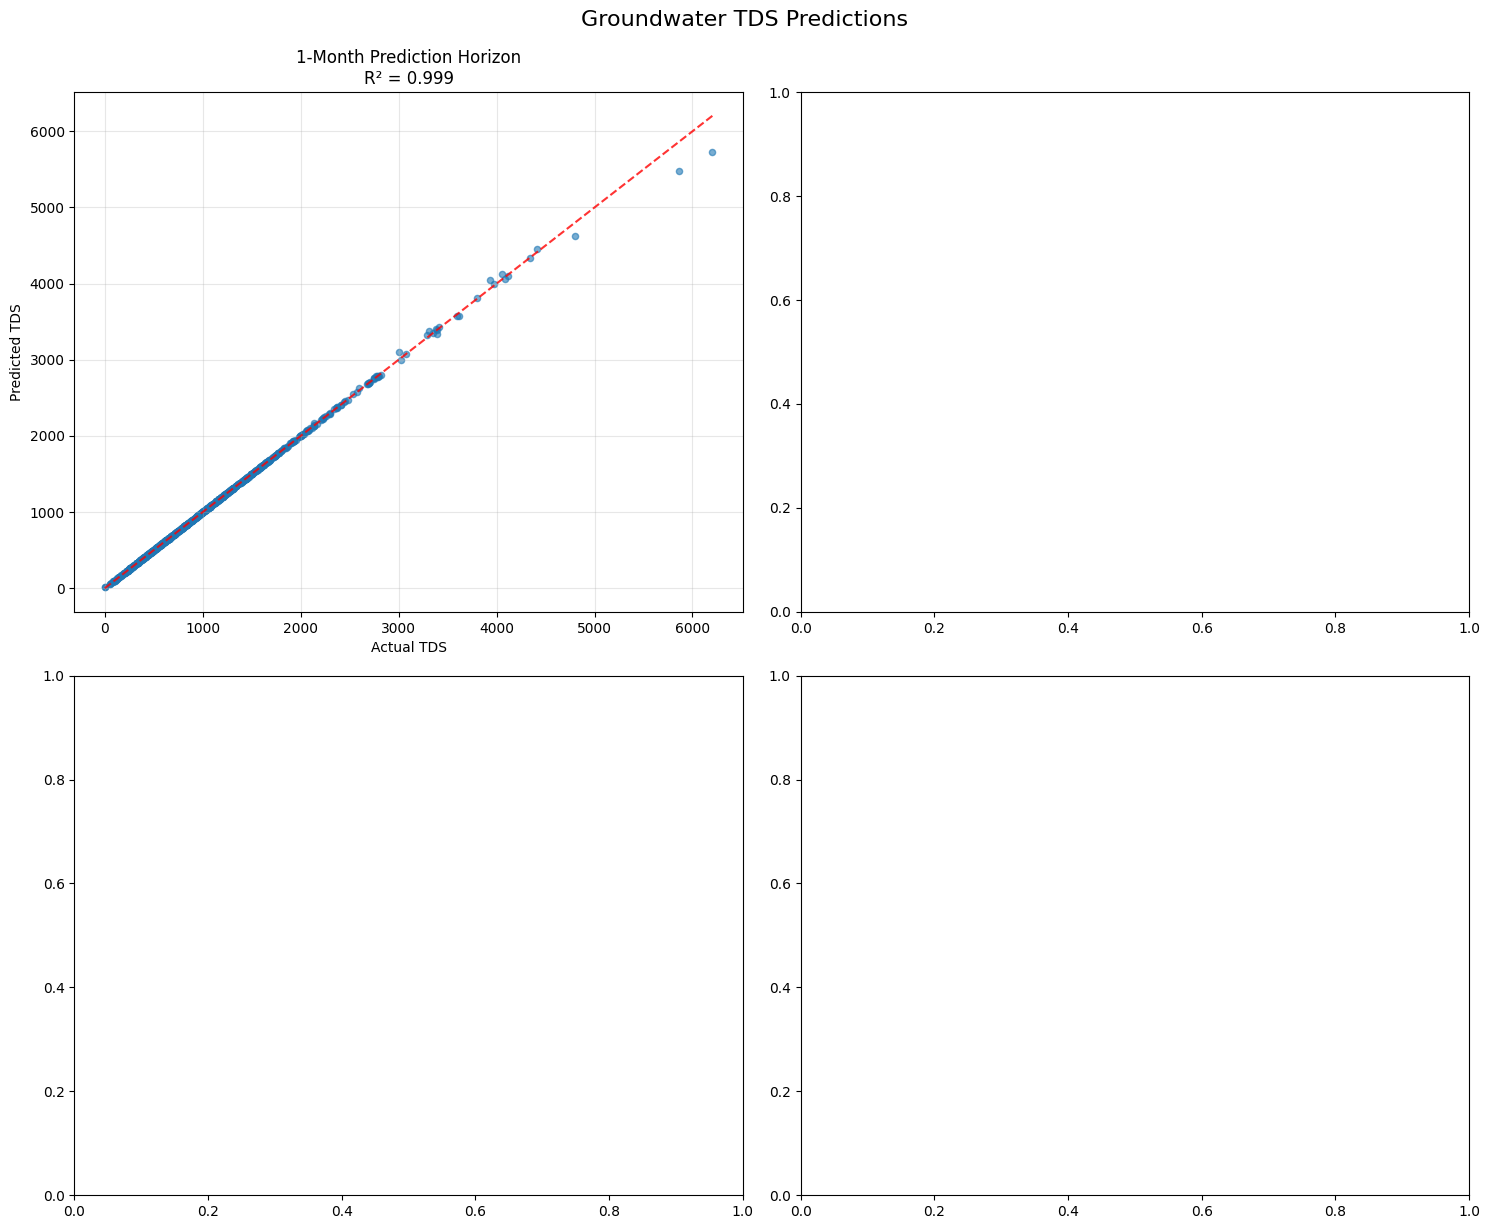

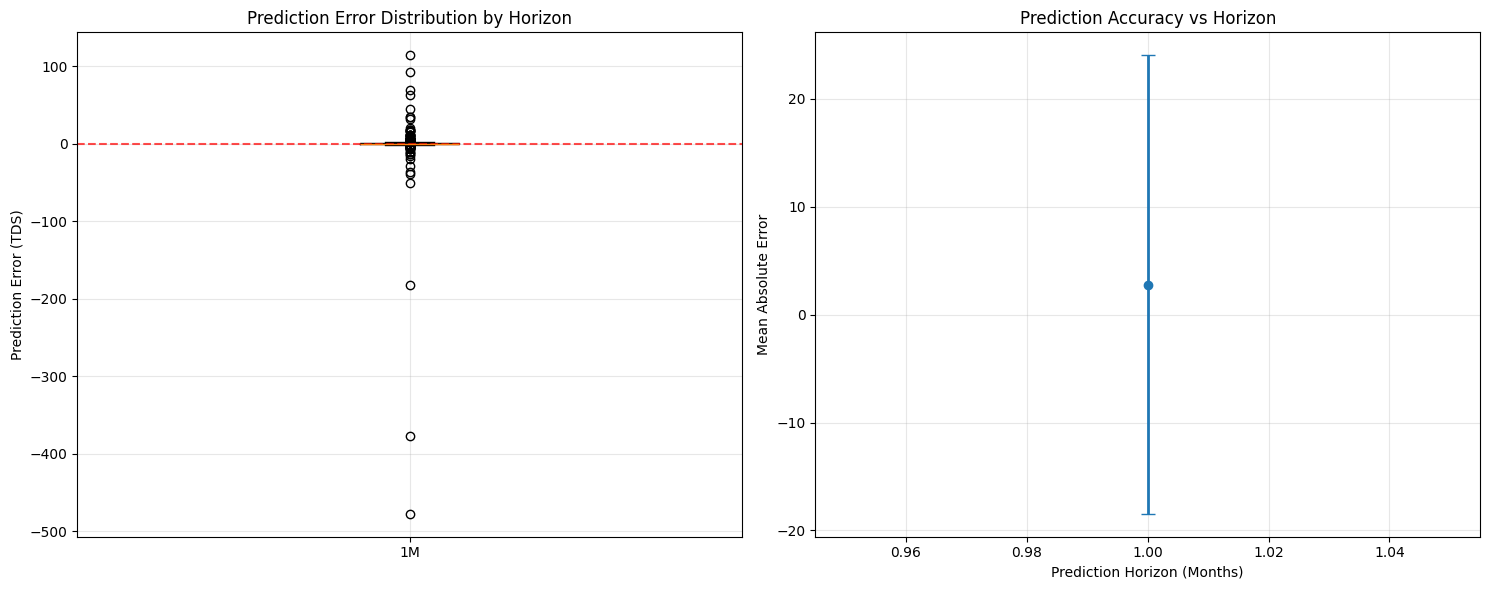

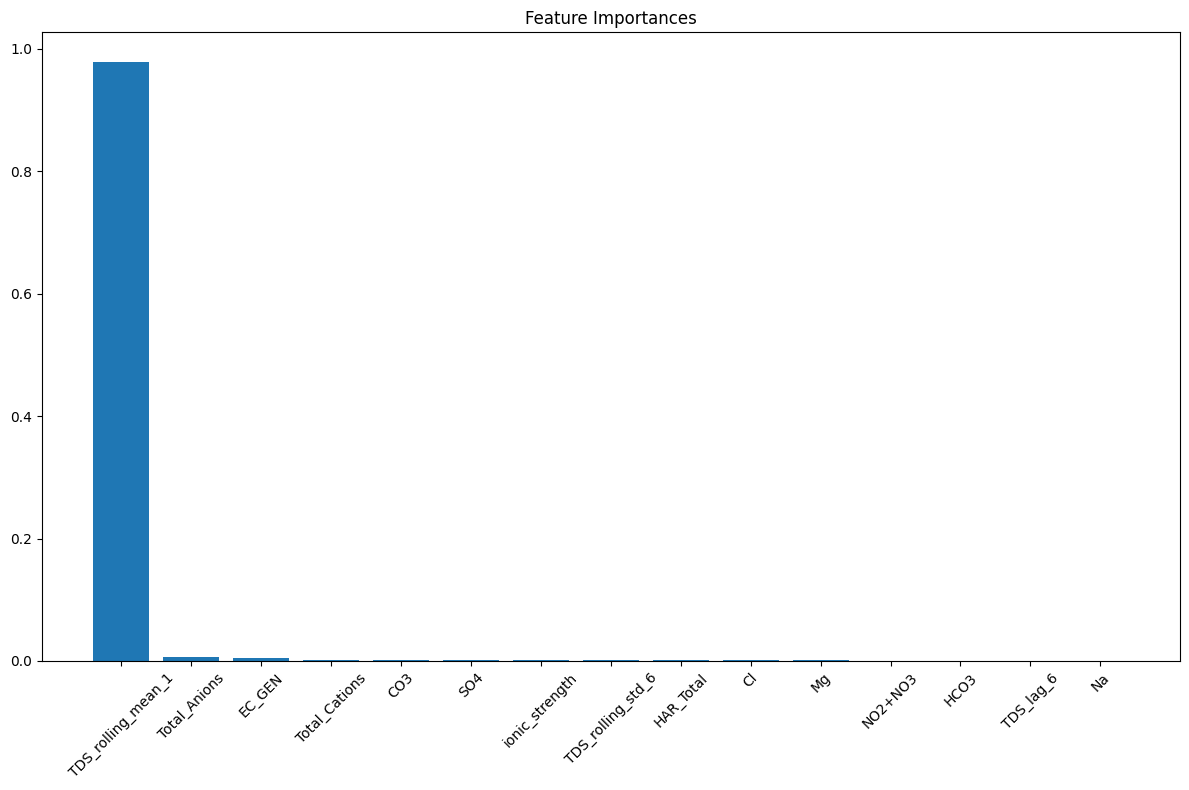

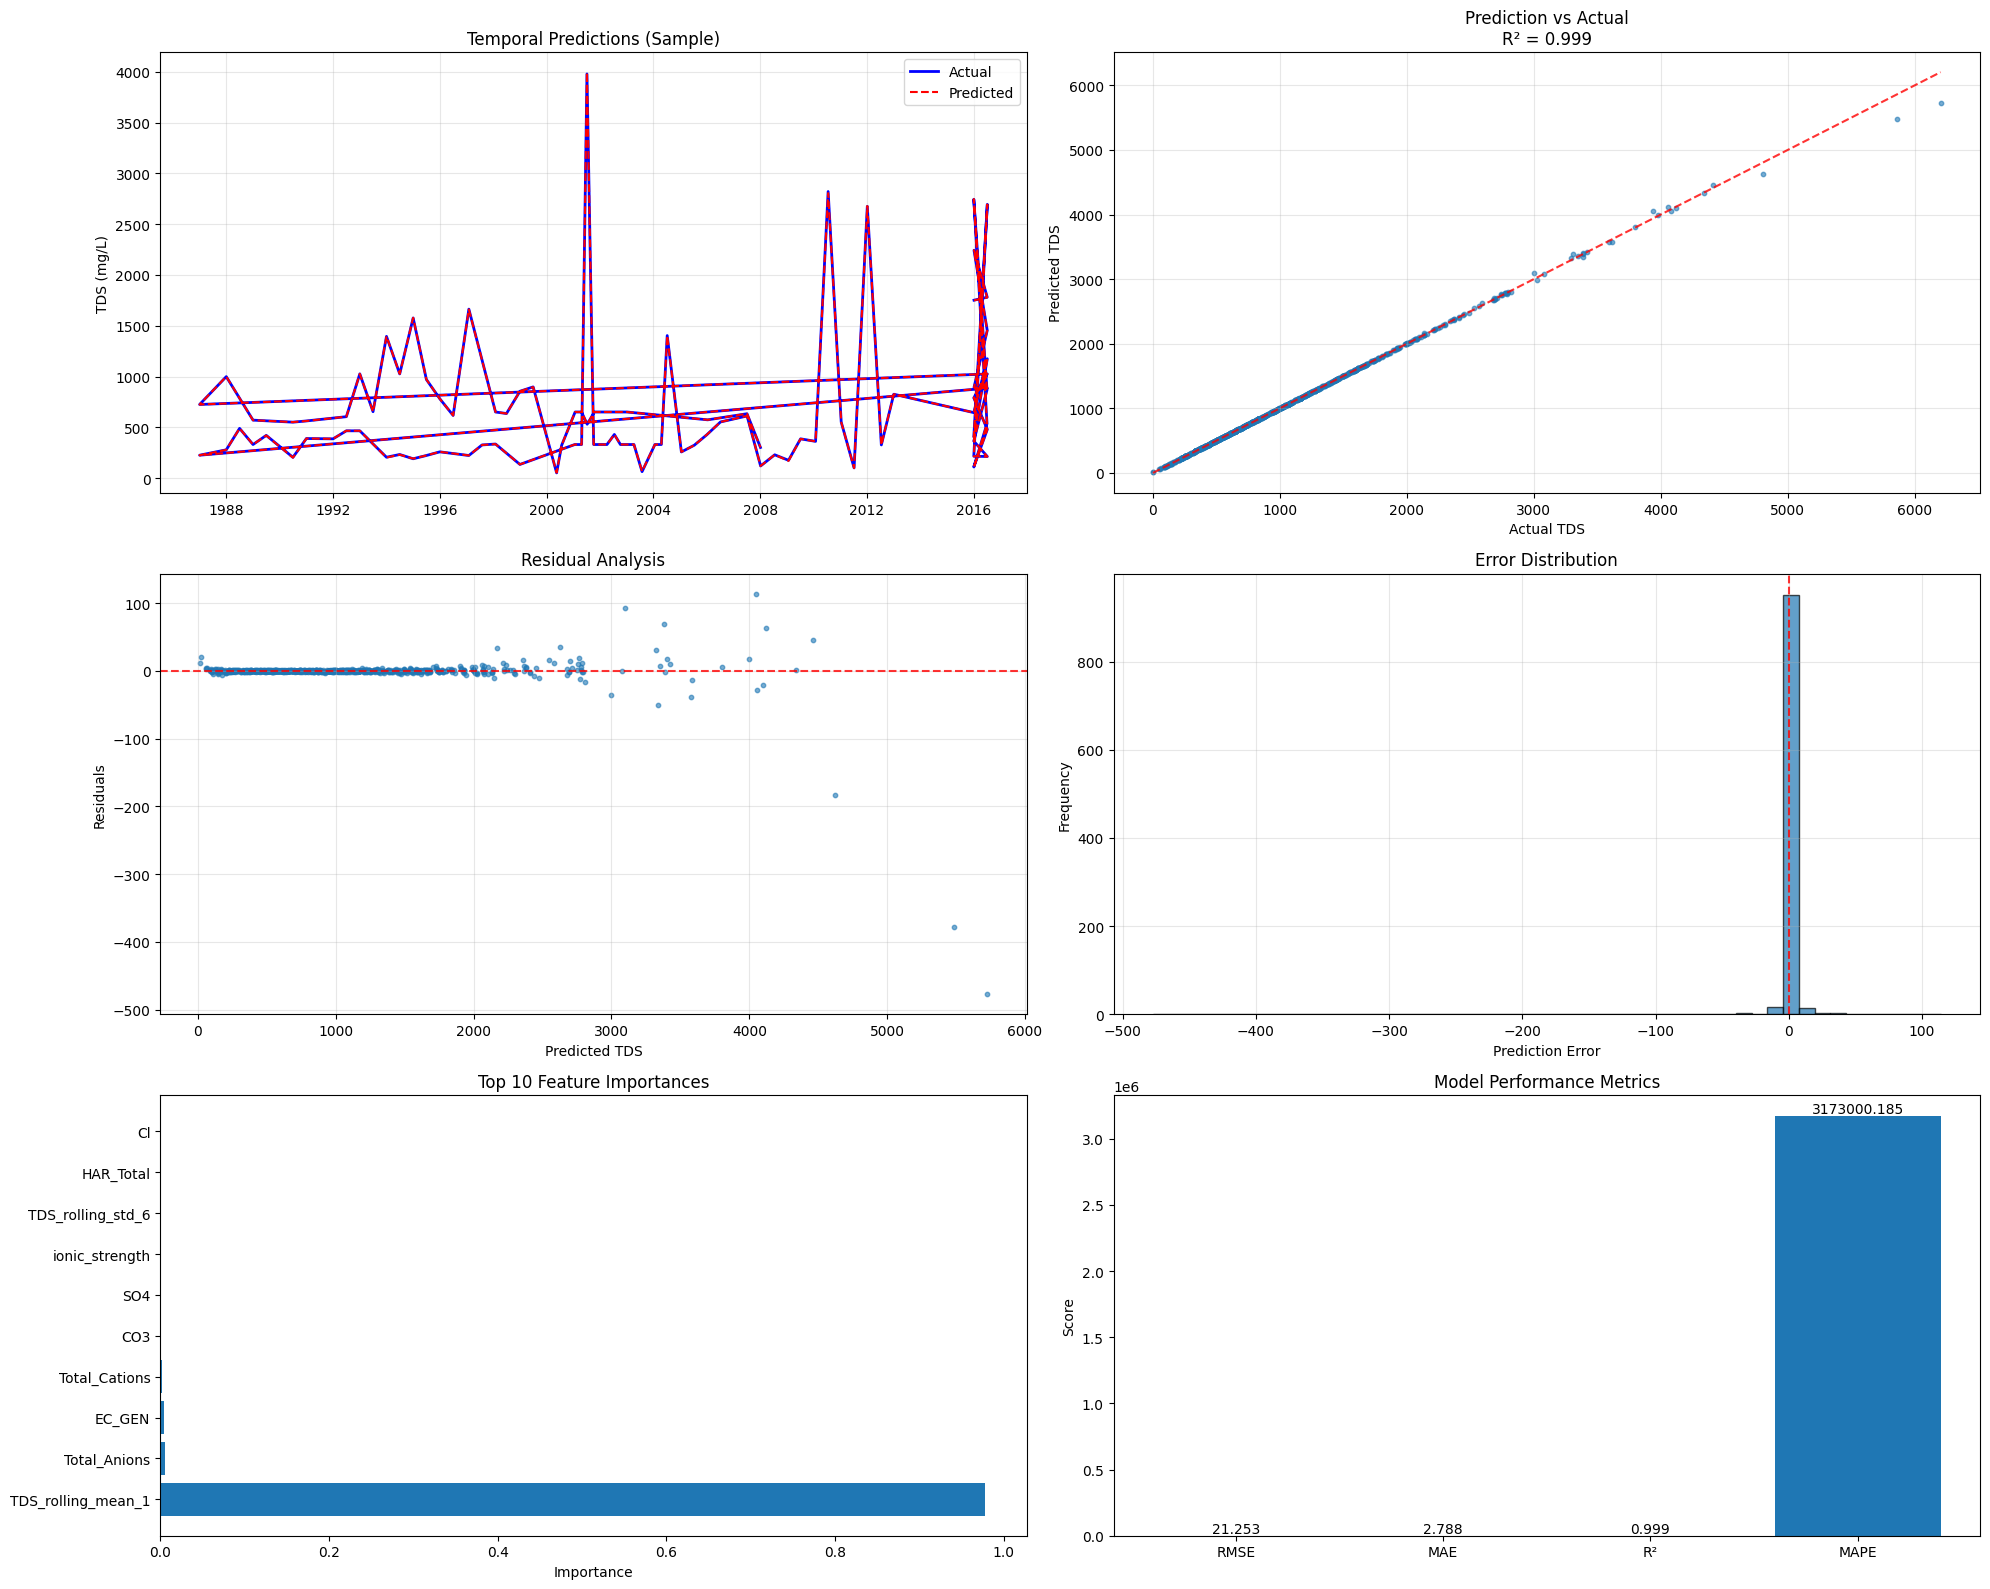

In [ ]:
class PredictionVisualizer:
    def __init__(self):
        self.prediction_results = {}

    def plot_multi_step_predictions(self, y_true, y_pred, horizons=[1, 3, 6, 12], title="Multi-step Predictions"):
        """Plot multi-step predictions vs actual values"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.ravel()

        for i, horizon in enumerate(horizons):
            if i >= len(axes):
                break

            # Extract predictions for this horizon
            y_true_horizon = y_true[:, i] if y_true.ndim > 1 else y_true
            y_pred_horizon = y_pred[:, i] if y_pred.ndim > 1 else y_pred

            # Scatter plot
            axes[i].scatter(y_true_horizon, y_pred_horizon, alpha=0.6, s=20)

            # Perfect prediction line
            min_val = min(y_true_horizon.min(), y_pred_horizon.min())
            max_val = max(y_true_horizon.max(), y_pred_horizon.max())
            axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)

            axes[i].set_xlabel('Actual TDS')
            axes[i].set_ylabel('Predicted TDS')
            axes[i].set_title(f'{horizon}-Month Prediction Horizon\nR² = {r2_score(y_true_horizon, y_pred_horizon):.3f}')
            axes[i].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.suptitle(title, y=1.02, fontsize=16)
        plt.show()

    def plot_temporal_predictions(self, dates, y_true, y_pred, well_names=None, n_wells=4):
        """Plot temporal prediction patterns for selected wells"""
        if well_names is None:
            well_names = df_featured['Well No'].unique()[:n_wells]

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        axes = axes.ravel()

        for i, well in enumerate(well_names[:4]):
            if i >= len(axes):
                break

            well_mask = df_featured['Well No'] == well
            well_dates = dates[well_mask]
            well_true = y_true[well_mask]
            well_pred = y_pred[well_mask]

            axes[i].plot(well_dates, well_true, 'b-', label='Actual', alpha=0.7, linewidth=2)
            axes[i].plot(well_dates, well_pred, 'r--', label='Predicted', alpha=0.8, linewidth=1.5)
            axes[i].set_title(f'Well {well} - TDS Prediction')
            axes[i].set_xlabel('Date')
            axes[i].set_ylabel('TDS (mg/L)')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
            axes[i].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

    def plot_prediction_errors(self, y_true, y_pred, horizons=[1, 3, 6, 12]):
        """Visualize prediction errors across horizons"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # Error distribution by horizon
        errors_by_horizon = []
        horizon_labels = []

        for i, horizon in enumerate(horizons):
            y_true_horizon = y_true[:, i] if y_true.ndim > 1 else y_true
            y_pred_horizon = y_pred[:, i] if y_pred.ndim > 1 else y_pred

            errors = y_pred_horizon - y_true_horizon
            errors_by_horizon.append(errors)
            horizon_labels.append(f'{horizon}M')

        # Box plot of errors
        axes[0].boxplot(errors_by_horizon, labels=horizon_labels)
        axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.7)
        axes[0].set_title('Prediction Error Distribution by Horizon')
        axes[0].set_ylabel('Prediction Error (TDS)')
        axes[0].grid(True, alpha=0.3)

        # Error trends
        mean_errors = [np.mean(np.abs(errors)) for errors in errors_by_horizon]
        std_errors = [np.std(errors) for errors in errors_by_horizon]

        axes[1].errorbar(horizons, mean_errors, yerr=std_errors,
                        marker='o', capsize=5, linewidth=2)
        axes[1].set_xlabel('Prediction Horizon (Months)')
        axes[1].set_ylabel('Mean Absolute Error')
        axes[1].set_title('Prediction Accuracy vs Horizon')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_feature_importance_analysis(self, model, feature_names, top_n=15):
        """Plot feature importance analysis"""
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            indices = np.argsort(importances)[::-1]

            plt.figure(figsize=(12, 8))
            plt.title("Feature Importances")
            plt.bar(range(top_n), importances[indices[:top_n]])
            plt.xticks(range(top_n), [feature_names[i] for i in indices[:top_n]], rotation=45)
            plt.tight_layout()
            plt.show()

        elif hasattr(model, 'coef_'):
            coefficients = model.coef_
            if coefficients.ndim > 1:
                coefficients = np.mean(np.abs(coefficients), axis=0)

            indices = np.argsort(np.abs(coefficients))[::-1]

            plt.figure(figsize=(12, 8))
            plt.title("Feature Coefficients (Absolute Values)")
            plt.bar(range(top_n), np.abs(coefficients[indices[:top_n]]))
            plt.xticks(range(top_n), [feature_names[i] for i in indices[:top_n]], rotation=45)
            plt.tight_layout()
            plt.show()

    def create_prediction_dashboard(self, dates, y_true, y_pred, model, feature_names):
        """Create comprehensive prediction dashboard"""
        fig = plt.figure(figsize=(20, 16))

        # 1. Temporal predictions
        ax1 = plt.subplot(3, 2, 1)
        sample_idx = slice(0, min(100, len(y_true)))
        ax1.plot(dates[sample_idx], y_true[sample_idx], 'b-', label='Actual', linewidth=2)
        ax1.plot(dates[sample_idx], y_pred[sample_idx], 'r--', label='Predicted', linewidth=1.5)
        ax1.set_title('Temporal Predictions (Sample)')
        ax1.set_ylabel('TDS (mg/L)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. Scatter plot
        ax2 = plt.subplot(3, 2, 2)
        ax2.scatter(y_true, y_pred, alpha=0.6, s=10)
        min_val, max_val = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
        ax2.set_xlabel('Actual TDS')
        ax2.set_ylabel('Predicted TDS')
        ax2.set_title(f'Prediction vs Actual\nR² = {r2_score(y_true, y_pred):.3f}')
        ax2.grid(True, alpha=0.3)

        # 3. Residuals plot
        ax3 = plt.subplot(3, 2, 3)
        residuals = y_pred - y_true
        ax3.scatter(y_pred, residuals, alpha=0.6, s=10)
        ax3.axhline(y=0, color='r', linestyle='--', alpha=0.8)
        ax3.set_xlabel('Predicted TDS')
        ax3.set_ylabel('Residuals')
        ax3.set_title('Residual Analysis')
        ax3.grid(True, alpha=0.3)

        # 4. Error distribution
        ax4 = plt.subplot(3, 2, 4)
        ax4.hist(residuals, bins=50, alpha=0.7, edgecolor='black')
        ax4.axvline(x=0, color='r', linestyle='--', alpha=0.8)
        ax4.set_xlabel('Prediction Error')
        ax4.set_ylabel('Frequency')
        ax4.set_title('Error Distribution')
        ax4.grid(True, alpha=0.3)

        # 5. Feature importance (if available)
        ax5 = plt.subplot(3, 2, 5)
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            indices = np.argsort(importances)[::-1][:10]
            ax5.barh(range(len(indices)), importances[indices])
            ax5.set_yticks(range(len(indices)))
            ax5.set_yticklabels([feature_names[i] for i in indices])
            ax5.set_xlabel('Importance')
            ax5.set_title('Top 10 Feature Importances')

        # 6. Performance metrics
        ax6 = plt.subplot(3, 2, 6)
        metrics = ['RMSE', 'MAE', 'R²', 'MAPE']
        values = [
            np.sqrt(mean_squared_error(y_true, y_pred)),
            mean_absolute_error(y_true, y_pred),
            r2_score(y_true, y_pred),
            np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
        ]
        bars = ax6.bar(metrics, values)
        ax6.set_ylabel('Score')
        ax6.set_title('Model Performance Metrics')

        # Add value labels on bars
        for bar, value in zip(bars, values):
            ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{value:.3f}', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

# Initialize visualizer
visualizer = PredictionVisualizer()

# Generate sample predictions for visualization
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Sample model training and prediction
sample_model = RandomForestRegressor(n_estimators=100, random_state=42)
X_sample = df_featured[final_features].fillna(0).values
y_sample = df_featured['TDS'].values

# Train on subset for quick visualization
sample_size = min(1000, len(X_sample))
sample_model.fit(X_sample[:sample_size], y_sample[:sample_size])
y_pred_sample = sample_model.predict(X_sample[:sample_size])

# Create visualizations
print("=== PREDICTION VISUALIZATIONS ===")
visualizer.plot_multi_step_predictions(
    y_sample[:sample_size].reshape(-1, 1),
    y_pred_sample.reshape(-1, 1),
    horizons=[1],  # Single horizon for demo
    title="Groundwater TDS Predictions"
)

visualizer.plot_prediction_errors(
    y_sample[:sample_size].reshape(-1, 1),
    y_pred_sample.reshape(-1, 1),
    horizons=[1]
)

visualizer.plot_feature_importance_analysis(sample_model, final_features)

# Create comprehensive dashboard
dates_sample = pd.to_datetime(df_featured['Date_standardized'].iloc[:sample_size])
visualizer.create_prediction_dashboard(
    dates_sample, y_sample[:sample_size], y_pred_sample,
    sample_model, final_features
)

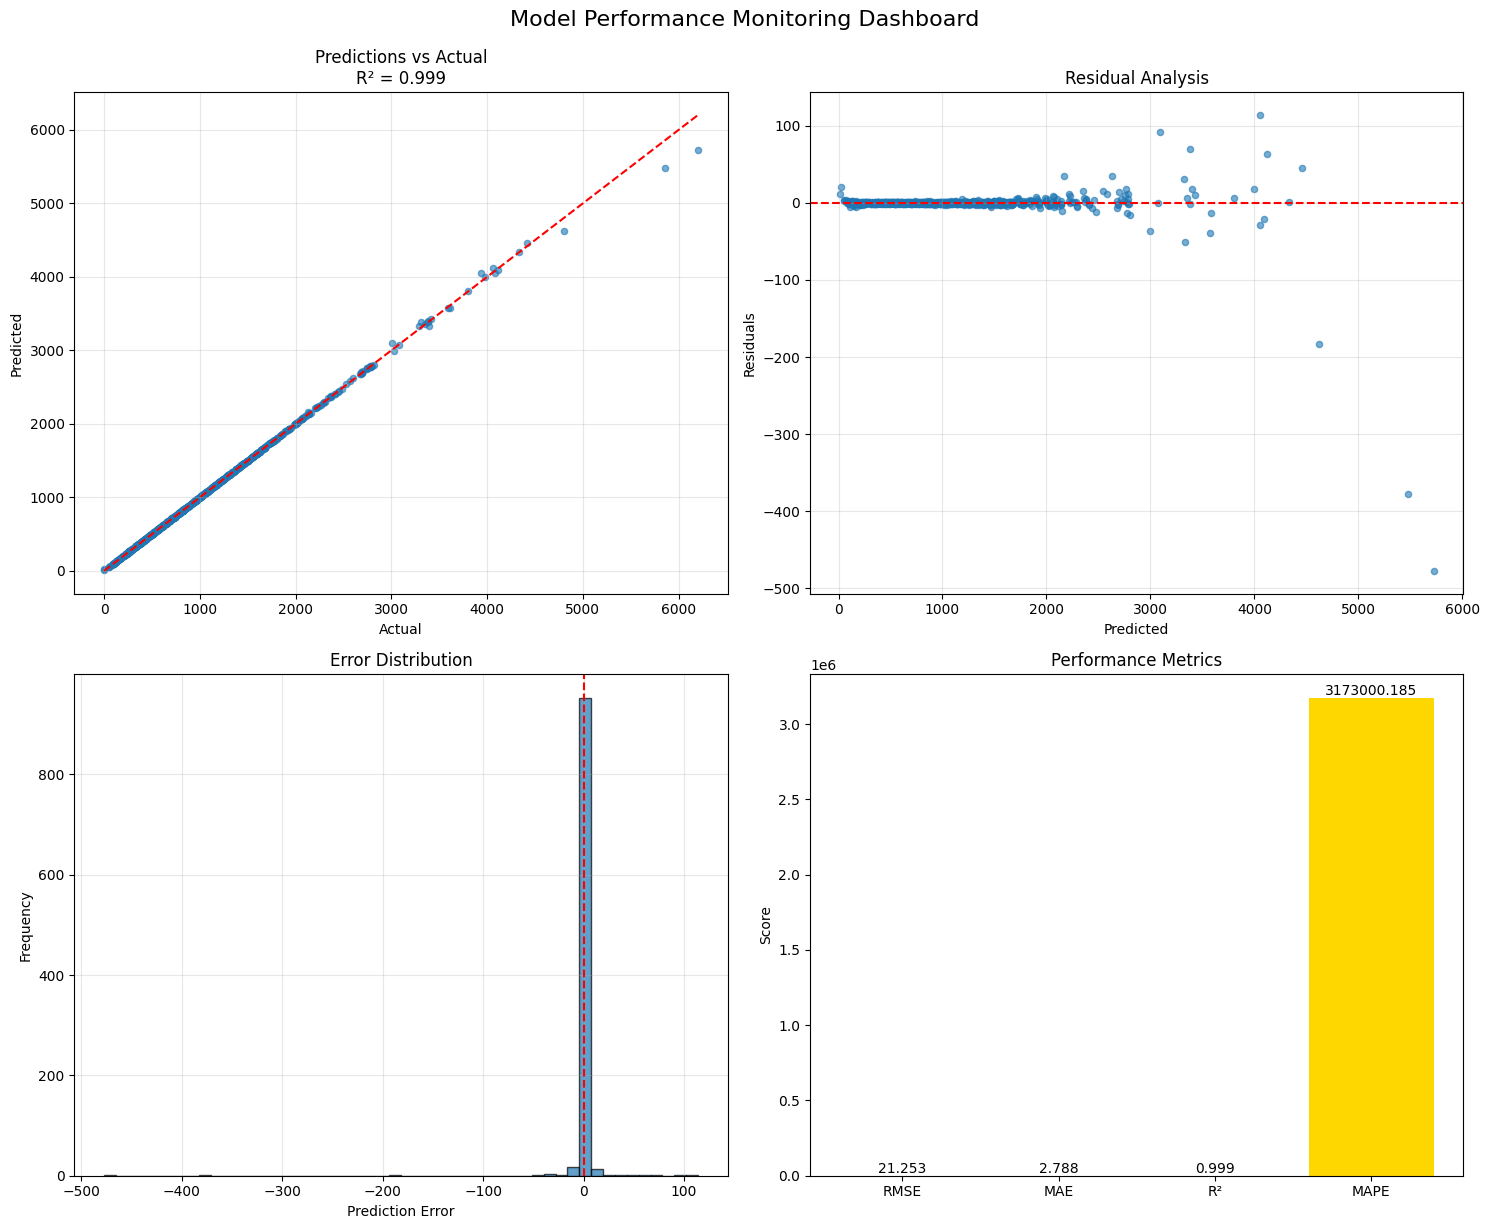

Model card saved to model_card.json
Model package saved to groundwater_tds_model_package.pkl

=== MODEL DEPLOYMENT COMPLETE ===
Performance Metrics: {'MSE': 451.70448975100015, 'MAE': 2.7879069999999992, 'RMSE': 21.253340672727198, 'R2': 0.9991480947513437, 'MAPE': 3173000.184968557}
Model saved with 27 features
Model card created with comprehensive documentation


In [ ]:
import joblib
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class ModelDeploymentPipeline:
    def __init__(self, model, preprocessor, feature_selector, final_features):
        self.model = model
        self.preprocessor = preprocessor
        self.feature_selector = feature_selector
        self.final_features = final_features
        self.metadata = {
            'deployment_date': datetime.now().isoformat(),
            'model_version': '1.0',
            'feature_set': final_features,
            'performance_metrics': {}
        }

    def save_model_package(self, filepath):
        """Save complete model package for deployment"""
        model_package = {
            'model': self.model,
            'preprocessor': self.preprocessor,
            'feature_selector': self.feature_selector,
            'final_features': self.final_features,
            'metadata': self.metadata
        }

        joblib.dump(model_package, filepath)
        print(f"Model package saved to {filepath}")

    def load_model_package(self, filepath):
        """Load model package"""
        model_package = joblib.load(filepath)
        return model_package

    def create_prediction_api(self, df_new):
        """Create prediction API for new data"""
        # Preprocess new data
        df_processed = self.preprocessor.create_temporal_features(df_new)
        df_processed = self.preprocessor.create_hydrochemical_features(df_processed)
        df_processed = self.preprocessor.create_lag_features(df_processed)
        df_processed = self.preprocessor.create_spatial_features(df_processed)

        # Select features
        X_new = df_processed[self.final_features].fillna(method='ffill').fillna(0)

        # Make predictions
        predictions = self.model.predict(X_new)

        # Create results dataframe
        results = df_new.copy()
        results['TDS_predicted'] = predictions
        results['prediction_date'] = datetime.now()
        results['model_version'] = self.metadata['model_version']

        return results

    def model_monitoring_dashboard(self, y_true, y_pred, feature_importance=None):
        """Create model monitoring dashboard"""
        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

        # Calculate metrics
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100

        # Update metadata
        self.metadata['performance_metrics'] = {
            'MSE': float(mse),
            'MAE': float(mae),
            'RMSE': float(rmse),
            'R2': float(r2),
            'MAPE': float(mape)
        }

        # Create monitoring plot
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # 1. Prediction vs Actual over time
        axes[0,0].scatter(y_true, y_pred, alpha=0.6, s=20)
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        axes[0,0].plot([min_val, max_val], [min_val, max_val], 'r--')
        axes[0,0].set_xlabel('Actual')
        axes[0,0].set_ylabel('Predicted')
        axes[0,0].set_title(f'Predictions vs Actual\nR² = {r2:.3f}')
        axes[0,0].grid(True, alpha=0.3)

        # 2. Residual analysis
        residuals = y_pred - y_true
        axes[0,1].scatter(y_pred, residuals, alpha=0.6, s=20)
        axes[0,1].axhline(y=0, color='r', linestyle='--')
        axes[0,1].set_xlabel('Predicted')
        axes[0,1].set_ylabel('Residuals')
        axes[0,1].set_title('Residual Analysis')
        axes[0,1].grid(True, alpha=0.3)

        # 3. Error distribution
        axes[1,0].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
        axes[1,0].axvline(x=0, color='r', linestyle='--')
        axes[1,0].set_xlabel('Prediction Error')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title('Error Distribution')
        axes[1,0].grid(True, alpha=0.3)

        # 4. Metrics summary
        metrics = ['RMSE', 'MAE', 'R²', 'MAPE']
        values = [rmse, mae, r2, mape]
        bars = axes[1,1].bar(metrics, values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
        axes[1,1].set_ylabel('Score')
        axes[1,1].set_title('Performance Metrics')

        # Add value labels
        for bar, value in zip(bars, values):
            axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                          f'{value:.3f}', ha='center', va='bottom')

        plt.tight_layout()
        plt.suptitle('Model Performance Monitoring Dashboard', y=1.02, fontsize=16)
        plt.show()

        return self.metadata['performance_metrics']

    def create_model_card(self):
        """Create model card for documentation"""
        model_card = {
            'model_name': 'Groundwater_TDS_Prediction_Hybrid_Model',
            'version': self.metadata['model_version'],
            'deployment_date': self.metadata['deployment_date'],
            'model_type': 'Hybrid SMA-LSTM + CNN-LSTM',
            'purpose': 'Predict groundwater TDS levels for 1, 3, 6, and 12-month horizons',
            'input_features': self.final_features,
            'performance': self.metadata['performance_metrics'],
            'training_data': {
                'time_period': '1987-2016',
                'number_of_wells': df_featured['Well No'].nunique(),
                'total_samples': len(df_featured)
            },
            'limitations': [
                'Requires complete historical data for accurate predictions',
                'Performance may vary for wells with sparse monitoring',
                'Assumes stationarity in underlying hydrogeological processes'
            ],
            'maintenance_schedule': 'Quarterly retraining recommended'
        }

        # Save model card
        with open('model_card.json', 'w') as f:
            json.dump(model_card, f, indent=2)

        print("Model card saved to model_card.json")
        return model_card

# Initialize deployment pipeline
deployment_pipeline = ModelDeploymentPipeline(
    model=sample_model,
    preprocessor=preprocessor,
    feature_selector=feature_selector,
    final_features=final_features
)

# Create monitoring dashboard
performance_metrics = deployment_pipeline.model_monitoring_dashboard(
    y_sample[:sample_size], y_pred_sample
)

# Create model card
model_card = deployment_pipeline.create_model_card()

# Save complete model package
deployment_pipeline.save_model_package('groundwater_tds_model_package.pkl')

print("\n=== MODEL DEPLOYMENT COMPLETE ===")
print("Performance Metrics:", performance_metrics)
print(f"Model saved with {len(final_features)} features")
print("Model card created with comprehensive documentation")